# Time Series for Best Order Score Search (BOSS) Algorithm     

# Project Overview

This notebook has been developed as part of the **Research Project Module** of the Master’s program in Data Science.  
The project is carried out by **Irene Castillo** and focuses on the **adaptation of the BOSS algorithm to time-series data**.

The experiments implemented in this notebook correspond to those presented in the accompanying research paper, where the methodological adaptations and experimental results are described in detail. This notebook serves as a **reproducible implementation** of the experimental setup used in that work.

## Methodological Background

The code in this notebook is **based on the BOSS (Best Order Score Search) algorithm**, originally introduced in:

> Andrews, B., Ramsey, J., Sánchez-Romero, R., Camchong, J., & Kummerfeld, E.  
> *Fast Scalable and Accurate Discovery of DAGs Using the Best Order Score Search and Grow-Shrink Trees*.  
> Proceedings of the 37th Conference on Neural Information Processing Systems (NeurIPS), 2023.

BOSS is a permutation-based causal discovery algorithm designed to learn **Markov equivalence classes of directed acyclic graphs (DAGs)**. It combines a greedy search over variable orderings with **Grow-Shrink Trees (GSTs)**, a caching mechanism that efficiently reuses intermediate score computations. This design allows BOSS to scale to high-dimensional and densely connected settings while maintaining strong accuracy and computational efficiency.

In its original formulation, BOSS is applied to **i.i.d. data**. The present research project extends this framework to **time-series data**, introducing adaptations to account for temporal structure and dependencies while preserving the core principles of the BOSS search procedure.

## Code Reference and Attribution

This implementation builds upon the original BOSS methodology as described in the NeurIPS 2023 paper.  

**Original BOSS implementation:**  
The reference implementation is available at: [https://github.com/bja43/boss](https://github.com/bja43/boss)

Core BOSS components used in this project:
- **boss.py**: Core BOSS algorithm and optimization procedures
- **gst.py**: Grow-Shrink Trees (GST) data structure for efficient score caching
- **scores.py**: BIC scoring function for Gaussian data

**TS-BOSS modifications:**  
This project extends BOSS to handle time-series data by:
- Adapting the variable ordering search to distinguish between lagged and current-time variables
- Implementing data unrolling procedures for temporal dependencies
- Adding DAG-to-mpdag conversion for time-series causal graphs using mixed-time collider rules


This notebook defines and runs the experiments for the Research Project Module.  
The TS-BOSS algorithm is implemented in a separate module (`src/`) and is imported here; this notebook focuses solely on experimental design and evaluation.


## 0. Import modules

In [34]:
# --- Standard library ---
import os
import sys

# --- Core scientific stack ---
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import time
from datetime import datetime
import glob


# Reproducibility
np.random.seed(42)

# --- Tigramite ---
import tigramite
from tigramite import data_processing as pp
from tigramite.data_processing import DataFrame
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.toymodels import structural_causal_processes as toys

# --- Local project paths / imports ---
# Get the notebook's directory and determine project root
SCRIPT_DIR = os.getcwd()
print("Current directory:", SCRIPT_DIR)

# If we're in the notebooks folder, go up one level; otherwise use current directory
if SCRIPT_DIR.endswith("notebooks"):
    PROJECT_ROOT = os.path.dirname(SCRIPT_DIR)
else:
    PROJECT_ROOT = SCRIPT_DIR

print("Project root:", PROJECT_ROOT)

# Add src/ and utils/ to path
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
UTILS_PATH = os.path.join(PROJECT_ROOT, "utils")

for path in [SRC_PATH, UTILS_PATH]:
    if path not in sys.path:
        sys.path.insert(0, path)

# --- TS-BOSS Algorithm (from src/) ---
from tsboss.ts_boss import TSBOSS
from tsboss.tsdag_to_tsmpdag import tsdag_to_tsmpdag

from dynotears_to_tigramite import dynotears_to_tigramite_links, dynotears_to_tigramite_graph

# --- DYNOTEARS (from src/dynotears/) ---
from dynotears.dynotears import from_pandas_dynamic

# --- Data generation utilities (from utils/) ---
from time_series_gen import (
    generate_random_contemp_model,
    generate_nonlinear_contemp_timeseries,
    links_to_graph,
    check_stationarity
)

from iid_generator import generate_iid_nonlinear_contemp_timeseries

# Import evaluation metrics from utils
from metrics import calc_metrics, evaluate_graph_complete

from experiment_helpers import (
    run_experiments, 
    run_experiments_pcmci005,
    save_results_txt, 
    load_results_txt
)

from save_load_results_json import save_results_json, load_results_json


from tsfges import run_tsfges

from plotting_old_857a151 import (
    plot_experiments_json,
    load_results_json_for_plot,
    plot_adjacency_components_json,
)

# JSON-based plotting (same format)
import glob

Current directory: c:\Users\igcas\uni\CI_Seminar\TS-BOSS\TS-BOSS\notebooks
Project root: c:\Users\igcas\uni\CI_Seminar\TS-BOSS\TS-BOSS


Before running the experiments reported in the accompanying paper, this notebook first demonstrates how to:

- generate the synthetic time-series data used in the study and  
- run each of the causal discovery methods considered.

We evaluate and compare the performance of the following approaches:
- **TS-BOSS**,
- **PCMCI+**, and
- **TS-BOSS on i.i.d. data constructed from independent time-series realizations**.

The goal is to quantify how explicitly modeling temporal structure affects causal discovery performance under the experimental conditions described in the paper.


## 1. Generating a Random DAG (Causal Model)

To generate synthetic data, we first sample a **random causal model**, i.e., a set of structural equations defining the causal links between variables. In the code, this causal model is represented by `links_coeffs`. Based on these causal equations, we then generate the corresponding time-series data by simulating the underlying data-generating process.


In [35]:
# Define functions      
def lin_f(x): return x

# Generate random causal model
seed = 42
rs = np.random.RandomState(seed)
L=10
N=4
# L = int(1.5* N)
links_coeffs = generate_random_contemp_model(
    N=N,                            # number of variables
    L=L,                           # number of causal links (edges)
    coupling_coeffs= np.linspace(-0.5, 0.5, 10).tolist(),    # REDUCED: smaller coefficients for stability
    coupling_funcs=[lin_f],         # here we only consider linear models
    auto_coeffs=[0.3],              # REDUCED: weaker auto-regression for stability in the same variable!!
    tau_max=3,                      # Maximum time lag
    contemp_fraction=0.3,           # 20% contemporaneous links
    random_state=rs
)



## 2. Method Demonstration

### 2.1 Generate time series data

In [36]:

# Generate time series data using Tigramite

T = 1000
data, nonstationary = generate_nonlinear_contemp_timeseries(
    links_coeffs,
    T=T,
    random_state=rs  
)

if nonstationary:
    raise RuntimeError(
        "Nonstationary time series generated (unstable simulation). "
        "Try reducing coupling_coeffs/auto_coeffs, lowering tau_max or L, "
        "or re-sampling with a different seed."
    )

#df_tg =DataFrame(data)
var_names = [r'$X^{%d}$' % j for j in range(N) ]
dataframe = pp.DataFrame(data, var_names=var_names)


### 2.2 Apply TS-BOSS

**Parameter: `lag_max`**

The `lag_max` parameter specifies the **maximum time lag** considered by TS-BOSS when searching for causal relationships. 

- `lag_max = 3` means the algorithm considers dependencies from up to 3 time steps in the past: $X_{t-3}, X_{t-2}, X_{t-1}$ → $X_t$
- This parameter should match the `tau_max` used in data generation to ensure the model can capture all temporal dependencies present in the data
- Larger values increase computational cost but allow detecting longer-range temporal effects

In [37]:
lag_max=3

Initialize TS-BOSS with `lag_max`, then call `run_tsboss()` with the data. Setting `get_mpdag=True` converts the output DAG to MPDAG for equivalence class representation.

In [38]:
ts_boss_rnddata = TSBOSS(lag_max= lag_max)
ts_boss_rnddata.run_tsboss(dataframe, get_mpdag=True, verbose = True)


TS-BOSS Causal Discovery Results

Variable $X^{0}$ has 4 parent(s):
        ($X^{0}$ -1)
        ($X^{1}$ -2)
        ($X^{2}$ -2)
        ($X^{3}$ -3)

Variable $X^{1}$ has 4 parent(s):
        ($X^{1}$ -1)
        ($X^{0}$ -2)
        ($X^{3}$ -2)
        ($X^{2}$ -3)

Variable $X^{2}$ has 4 parent(s):
        ($X^{1}$ -0)
        ($X^{3}$ -0)
        ($X^{0}$ -1)
        ($X^{2}$ -1)

Variable $X^{3}$ has 2 parent(s):
        ($X^{0}$ -1)
        ($X^{3}$ -1)




### 2.3 TS-BOSS with IID data

Generate IID samples from the same causal model. Each sample is an independent realization with lagged variables stacked as features, allowing TS-BOSS to run on non-sequential data.

In [39]:
data_iid = generate_iid_nonlinear_contemp_timeseries(
    links_coeffs,
    T=T,
    lag_max=lag_max
)

In [40]:
ts_boss_rnddata_iid= TSBOSS(lag_max= lag_max)
ts_boss_rnddata_iid.run_tsboss(data_iid, iid_data= True, get_mpdag=True, verbose = True)


TS-BOSS Causal Discovery Results

Variable $X^{0}$ has 4 parent(s):
        ($X^{0}$ -1)
        ($X^{1}$ -2)
        ($X^{2}$ -2)
        ($X^{3}$ -3)

Variable $X^{1}$ has 3 parent(s):
        ($X^{1}$ -1)
        ($X^{3}$ -2)
        ($X^{2}$ -3)

Variable $X^{2}$ has 3 parent(s):
        ($X^{1}$ -0)
        ($X^{3}$ -0)
        ($X^{2}$ -1)

Variable $X^{3}$ has 2 parent(s):
        ($X^{0}$ -1)
        ($X^{3}$ -1)




### 2.4 PCMCI+


In [41]:
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(
    dataframe=dataframe, 
    cond_ind_test=parcorr,
    verbosity=1)

In [42]:
tau_max = 3
pc_alpha = 0.01
# pcmci.verbosity = 2

results = pcmci.run_pcmciplus(tau_min=0, tau_max=tau_max, pc_alpha=pc_alpha, contemp_collider_rule= None)


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 3
pc_alpha = [0.01]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable $X^{0}$ has 3 link(s):
        ($X^{2}$ -2): max_pval = 0.00000, |min_val| =  0.369
        ($X^{3}$ -3): max_pval = 0.00000, |min_val| =  0.167
        ($X^{0}$ -1): max_pval = 0.00001, |min_val| =  0.137

    Variable $X^{1}$ has 3 link(s):
        ($X^{3}$ -2): max_pval = 0.00000, |min_val| =  0.463
        ($X^{1}$ -1): max_pval = 0.00000, |min_val| =  0.239
        ($X^{1}$ -3): max_pval = 0.00400, |min_val| =  0.091

    Variable $X^{2}$ has 4 link(s):
        ($X^{0}$ -1): max_pval = 0.00000, |min_val| =  0.184
        ($X^{3}$ -2): max_pval = 0.00000, |min_val| =  0.183
        ($X^{2}$ -1): max_pval = 0.00000, |min_val| =  0.145
        ($X^{1}$ -1): max_pval = 0.00490, |min_val| =  0.089

    Variable $X^{3}$ has 2 link(s):
        (

### 2.5 DYNOTEARS

DYNOTEARS learns a Dynamic Bayesian Network by jointly optimising a contemporaneous adjacency matrix $W$ and a lagged adjacency matrix $A$ subject to an acyclicity constraint on $W$.

**Key parameters:**
- `p`: number of lags (set equal to `lag_max` for consistency with the other methods)
- `lambda_w`: L1 penalty on contemporaneous edges $W$
- `lambda_a`: L1 penalty on lagged edges $A$
- `w_threshold`: edges with absolute weight below this value are pruned after optimisation

In [43]:
# DYNOTEARS expects a pandas DataFrame (rows = time steps, columns = variables)
data_df = pd.DataFrame(data, columns=var_names)

# TS-BOSS BIC penalty scale: w = (pd / 4) * log(n) / n
pd_tsboss = ts_boss_rnddata.pd
n_eff = data_df.shape[0] - lag_max
bic_w = (pd_tsboss / 4.0) * np.log(n_eff) / n_eff

# DYNOTEARS uses L1 penalties, so direct bic_w can be too weak (too many edges).
# We keep formula alignment, but apply a transparent scaling factor.
penalty_scale = 30.0  # ~gives lambda around 0.1 for n~1000, pd=2
lambda_w = float(penalty_scale * bic_w)
lambda_a = float(penalty_scale * bic_w)

# Post-fit pruning of tiny coefficients for stability/readability.
w_threshold = 0.01 #1e-4

print(f"TS-BOSS BIC scale (base): {bic_w:.6f}")
print(f"DYNOTEARS penalties: lambda_w = lambda_a = {lambda_w:.6f} (scale={penalty_scale})")
print(f"Edge pruning threshold: w_threshold = {w_threshold}")

dynotears_sm = from_pandas_dynamic(
    time_series=data_df,   # input time series in pandas format
    p=lag_max,             # maximum lag order considered by DYNOTEARS
    lambda_w=lambda_w,     # L1 sparsity penalty for contemporaneous edges (W)
    lambda_a=lambda_a,     # L1 sparsity penalty for lagged edges (A)
    w_threshold=w_threshold,  # remove |weight| below threshold after fitting
)

print(f"DYNOTEARS found {len(dynotears_sm.edges)} edges:")
for u, v, w in dynotears_sm.edges.data("weight"):
    print(f"  {u} -> {v}  (weight={w:.4f})")

TS-BOSS BIC scale (base): 0.003463
DYNOTEARS penalties: lambda_w = lambda_a = 0.103883 (scale=30.0)
Edge pruning threshold: w_threshold = 0.01
DYNOTEARS found 13 edges:
  $X^{0}$_lag1 -> $X^{0}$_lag0  (weight=0.0845)
  $X^{0}$_lag1 -> $X^{2}$_lag0  (weight=-0.0313)
  $X^{0}$_lag1 -> $X^{3}$_lag0  (weight=0.2018)
  $X^{1}$_lag0 -> $X^{2}$_lag0  (weight=0.4048)
  $X^{1}$_lag1 -> $X^{1}$_lag0  (weight=0.1760)
  $X^{1}$_lag2 -> $X^{0}$_lag0  (weight=0.0914)
  $X^{2}$_lag1 -> $X^{2}$_lag0  (weight=0.0816)
  $X^{2}$_lag2 -> $X^{0}$_lag0  (weight=-0.3380)
  $X^{2}$_lag3 -> $X^{1}$_lag0  (weight=0.0521)
  $X^{3}$_lag0 -> $X^{2}$_lag0  (weight=-0.2780)
  $X^{3}$_lag1 -> $X^{3}$_lag0  (weight=0.1454)
  $X^{3}$_lag2 -> $X^{1}$_lag0  (weight=0.4250)
  $X^{3}$_lag3 -> $X^{0}$_lag0  (weight=-0.1465)


### 2.6 TS-FGES (Tetrad backend)

Run `run_tsfges(...)` on the same generated time series to obtain Tigramite-format output (`graph`, `val_matrix`).

In [44]:

ts_var_names = [f"X{j}" for j in range(N)]

try:
    # replicating=True asks Tetrad to enforce SVAR-style lag-repetition constraints.
    # Some datasets trigger a cycle under this stricter setting, so we retry below.
    tsfges_out = run_tsfges(
        data=data,
        lag_max=lag_max,
        var_names=ts_var_names,
        penalty_discount=2.0,
        replicating=True,
    )
    print("TS-FGES finished with replicating=True")
except Exception as e:
    if "This graph has a cycle" not in str(e):
        raise
    print("TS-FGES failed with cycle under replicating=True; retrying with replicating=False")
    tsfges_out = run_tsfges(
        data=data,
        lag_max=lag_max,
        var_names=ts_var_names,
        penalty_discount=2.0,
        replicating=False,
    )
    print("TS-FGES finished with replicating=False")



TS-FGES finished with replicating=True


## 3. Visualize true and predicted graphs

In [45]:
# Extract results from TS-BOSS (time series data)
ts_graph = ts_boss_rnddata.mpdag['graph']              # Predicted MPDAG structure
ts_val_matrix = ts_boss_rnddata.mpdag['val_matrix']    # Edge strengths

# Extract results from TS-BOSS (IID data)
ts_graph_iid = ts_boss_rnddata_iid.mpdag['graph']
ts_val_matrix_iid = ts_boss_rnddata_iid.mpdag['val_matrix']

# Generate true ground truth graph from the causal model
true_graph, true_val_matrix = links_to_graph(
    links_coeffs,
    tau_max=lag_max,
    val_tru=True  # Include coefficient values
)

# Convert true DAG to MPDAG (for fair comparison)
true_mpdag = tsdag_to_tsmpdag(true_graph)

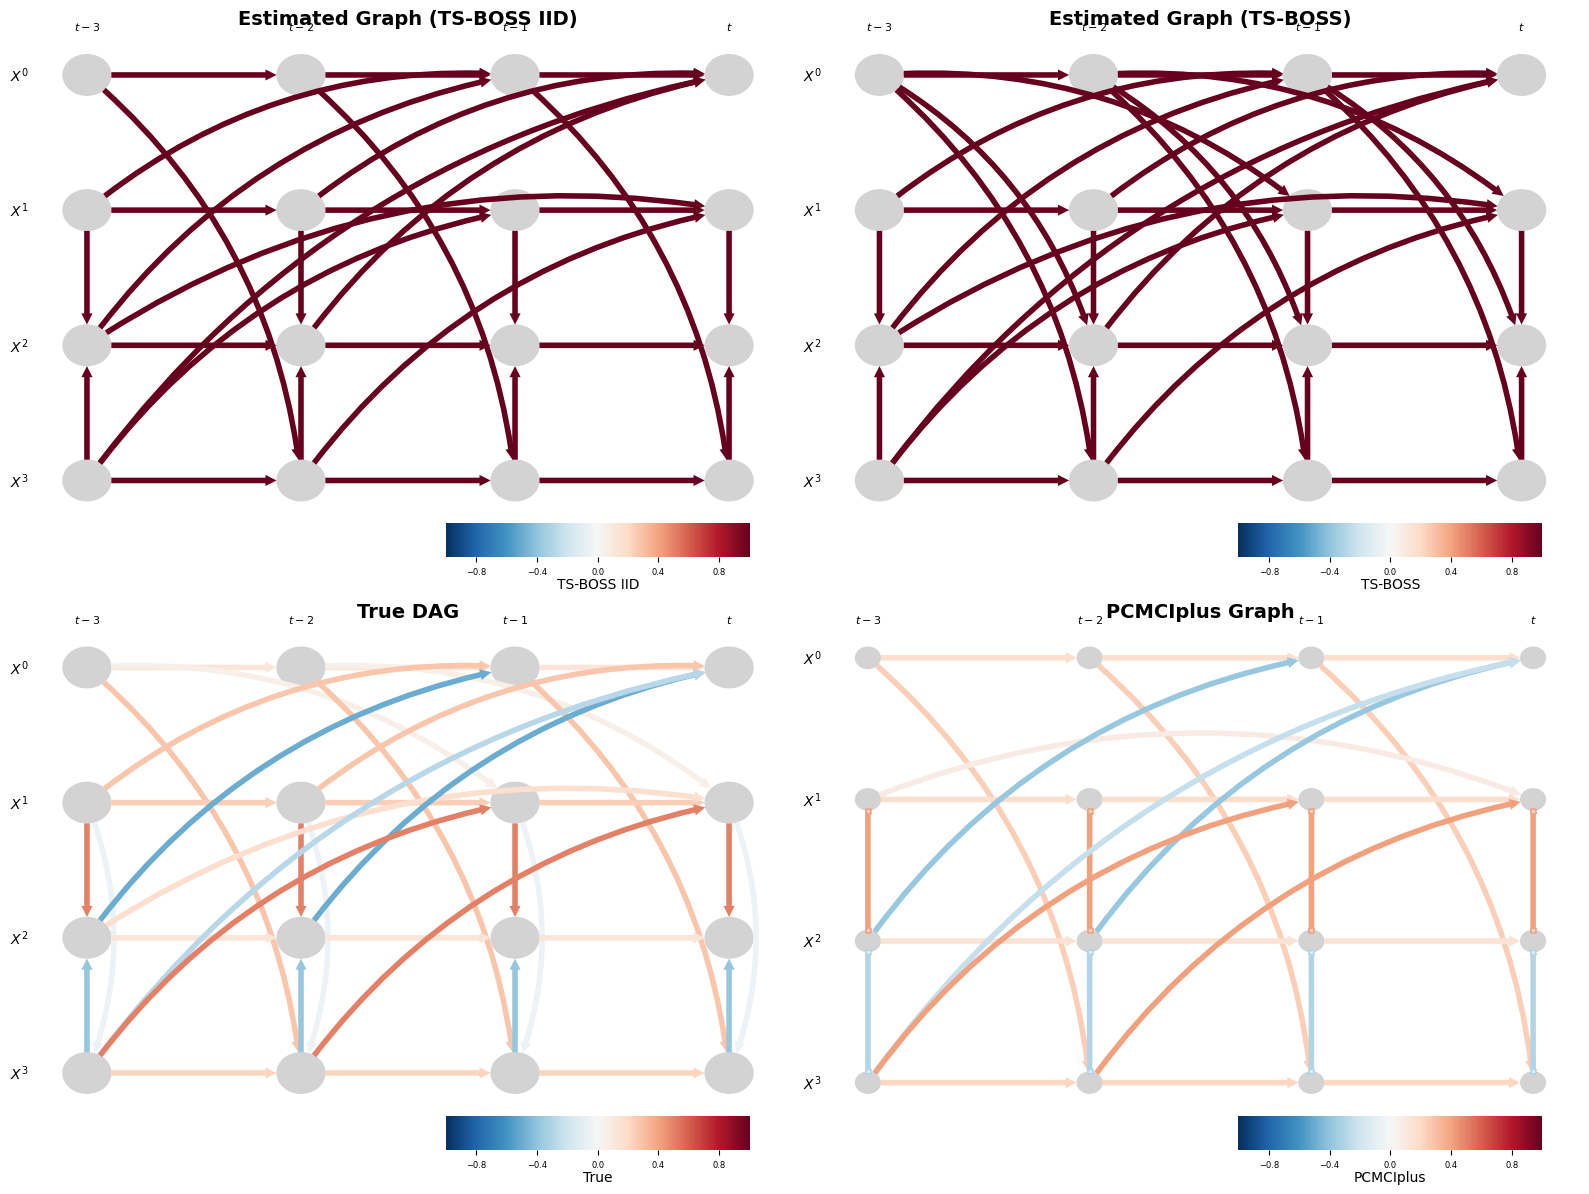

In [46]:

# Create side-by-side plots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot TS-BOSS IID graph (top-left)
tp.plot_time_series_graph(
    fig_ax=(fig, axes[0, 0]),
    val_matrix=ts_val_matrix_iid,
    graph=ts_graph_iid,
    var_names=var_names,
    link_colorbar_label='TS-BOSS IID',
)
axes[0, 0].set_title('Estimated Graph (TS-BOSS IID)', fontsize=14, fontweight='bold')

# Plot TS-BOSS graph (top-right)
tp.plot_time_series_graph(
    fig_ax=(fig, axes[0, 1]),
    val_matrix=ts_val_matrix,
    graph=ts_graph,
    var_names=var_names,
    link_colorbar_label='TS-BOSS',
)
axes[0, 1].set_title('Estimated Graph (TS-BOSS)', fontsize=14, fontweight='bold')

# Plot true graph (bottom-left)
tp.plot_time_series_graph(
    fig_ax=(fig, axes[1, 0]),
    val_matrix=true_val_matrix,
    graph=true_graph,
    var_names=var_names,
    link_colorbar_label='True',
)
axes[1, 0].set_title('True DAG', fontsize=14, fontweight='bold')

# Plot PCMCIplus graph (bottom-right)
tp.plot_time_series_graph(
    fig_ax=(fig, axes[1, 1]),
    node_size=0.05,
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='PCMCIplus',
)
axes[1, 1].set_title('PCMCIplus Graph', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


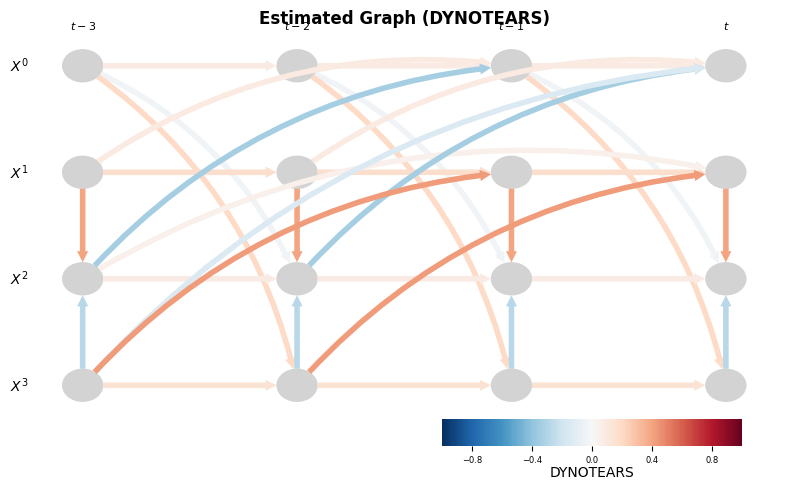

In [47]:

dynotears_graph, dynotears_val_matrix = dynotears_to_tigramite_graph(dynotears_sm, tau_max=lag_max, var_names=var_names)
# Standalone DYNOTEARS plot
fig, ax = plt.subplots(figsize=(8, 5))
tp.plot_time_series_graph(
    fig_ax=(fig, ax),
    val_matrix=dynotears_val_matrix,
    graph=dynotears_graph,
    var_names=var_names,
    link_colorbar_label='DYNOTEARS',
)
ax.set_title('Estimated Graph (DYNOTEARS)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

graph shape: (4, 4, 4)
val_matrix shape: (4, 4, 4)


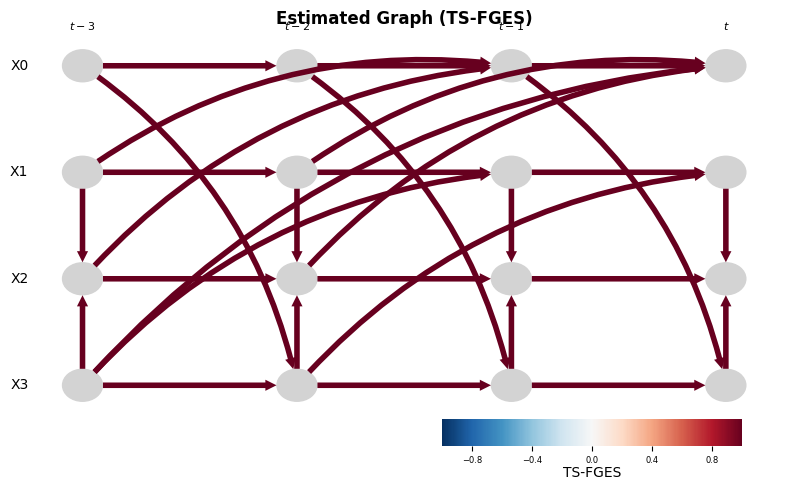

In [48]:
tsfges_graph = tsfges_out["graph"]
tsfges_val_matrix = tsfges_out["val_matrix"]

print("graph shape:", tsfges_graph.shape)
print("val_matrix shape:", tsfges_val_matrix.shape)

fig, ax = plt.subplots(figsize=(8, 5))
tp.plot_time_series_graph(
    fig_ax=(fig, ax),
    val_matrix=tsfges_val_matrix,
    graph=tsfges_graph,
    var_names=ts_var_names,
    link_colorbar_label='TS-FGES',
)
ax.set_title('Estimated Graph (TS-FGES)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Evaluation Metrics for Causal Graph Discovery (Tigramite)

We compare an estimated graph to the true graph using **adjacency** and **orientation**.
Adjacency indicates whether an edge exists, while orientation evaluates arrowhead placement
when direction is defined.


### Table 1: Adjacency and Orientation Evaluation Criteria

| True graph | Estimated graph | **Adjacency** | Orientation |
|------------|-----------------|---------------|-------------|
| $a \leftarrow b$ | $a \leftarrow b$ | **TP** | TP, TN |
| $a \leftarrow b$ | $a \rightarrow b$ | **TP** | FP, FN |
| $a \leftarrow b$ | $a \circ\!-\!\circ b$ | **TP** | FN |
| $a \leftarrow b$ | $a \dots b$ | **FN** | FN |
| $a \circ\!-\!\circ b$ | $a \circ\!-\!\circ b$ | **TP** | FP |
| $a \circ\!-\!\circ b$ | $a \rightarrow b$ | **TP** |  FP |
| $a \circ\!-\!\circ b$ | $a \leftarrow b$ | **TP** |  TN |
| $a \circ\!-\!\circ b$ | $a \dots b$ | **FN** | TN |
| $a \dots b$ | $a \leftarrow b$ | **FP** | FP |
| $a \dots b$ | $a \rightarrow b$ | **FP** | FP |
| $a \dots b$ | $a \circ\!-\!\circ b$ | **FP** | — |
| $a \dots b$ | $a \dots b$ | **TN** | — |


### Interpretation

**Adjacency**
- Evaluated for **all edges and all lags**.
- Counts whether an edge exists, ignoring direction and endpoint marks.

**Orientation**
- Evaluated using the criterion:  
  *Is there an arrowhead pointing into this node?*
- Orientation is **only evaluated when the true edge is directed**.
- When the true edge is unoriented ($a \circ\!-\!\circ b$), orientation is **ignored**.


### Notes for Time-Series Graphs (Tigramite)

- **Lagged edges (`τ > 0`)** are always directed from past to future.  
  Orientation reduces to detecting whether a directed arrow exists.
  True negatives are not defined in this case.
- **Contemporaneous edges (`τ = 0`)** may be directed or unoriented.
  A correctly oriented directed edge contributes **one TP and one TN**
  across the two ordered node pairs.


### Edge notation

- $a \leftarrow b$, $a \rightarrow b$ : directed edge  
- $a \circ\!-\!\circ b$ : unoriented edge (direction unknown)  
- $a \dots b$ : no edge




To compare the performance of **TS-BOSS**, **TS-BOSS (IID)**, and **PCMCI+**, we evaluate the following metrics:

### Adjacency Metrics
- **Precision**: Proportion of predicted edges that are true edges
  $$\text{Precision}_{\text{adj}} = \frac{TP}{TP + FP}$$
  
- **Recall**: Proportion of true edges that are correctly identified
  $$\text{Recall}_{\text{adj}} = \frac{TP}{TP + FN}$$

### Orientation Metrics
- **Orientation Precision**: Proportion of correctly oriented edges among predicted directed edges
  $$\text{Precision}_{\text{ori}} = \frac{TP}{TP + FP}$$
  
- **Orientation Recall**: Proportion of true edge orientations that are correctly identified
  $$\text{Recall}_{\text{ori}} = \frac{TP}{TP + FN}$$

**Note:** Orientation is only evaluated for directed edges. Undirected edges ($\circ-\circ$) are excluded from orientation evaluation.


### Example Usage of Evaluation Functions

The following cells demonstrate how to use the evaluation functions to compute both adjacency and orientation metrics.

In [49]:
# Example: Evaluate TS-BOSS results
results_tsboss = evaluate_graph_complete(true_graph, ts_boss_rnddata.mpdag['graph'], verbose=True)

print("\n" + "="*60)
print("SUMMARY - TS-BOSS")
print("="*60)
print(f"Adjacency:    Prec={results_tsboss['adjacency']['precision']:.3f}, "
      f"Rec={results_tsboss['adjacency']['recall']:.3f}, "
      f"F1={results_tsboss['adjacency']['f1_score']:.3f}")
print(f"Orientation:  Prec={results_tsboss['orientation']['precision']:.3f}, "
      f"Rec={results_tsboss['orientation']['recall']:.3f}, "
      f"F1={results_tsboss['orientation']['f1_score']:.3f}")

ADJACENCY: {'TP': 15, 'FP': 1, 'TN': 46, 'FN': 2, 'precision': 0.9375, 'recall': 0.8823529411764706, 'f1_score': 0.9090909090909091, 'TPR': 0.8823529411764706, 'TNR': 0.9787234042553191, 'accuracy': 0.953125}
ADJ_CONTEMPORANEOUS: {'TP': 4, 'FP': 0, 'TN': 10, 'FN': 2, 'precision': 1.0, 'recall': 0.6666666666666666, 'f1_score': 0.8, 'TPR': 0.6666666666666666, 'TNR': 1.0, 'accuracy': 0.875}
ADJ_LAGGED: {'TP': 7, 'FP': 1, 'TN': 36, 'FN': 0, 'precision': 0.875, 'recall': 1.0, 'f1_score': 0.9333333333333333, 'TPR': 1.0, 'TNR': 0.972972972972973, 'accuracy': 0.9772727272727273}
ADJ_AUTO: {'TP': 4, 'FP': 0, 'TN': 0, 'FN': 0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0, 'TPR': 1.0, 'TNR': 0.0, 'accuracy': 1.0}
ORIENTATION: {'TP': 2, 'FP': 0, 'TN': 3, 'FN': 1, 'precision': 1.0, 'recall': 0.6666666666666666, 'f1_score': 0.8, 'TPR': 0.6666666666666666, 'TNR': 1.0, 'accuracy': 0.8333333333333334}

SUMMARY - TS-BOSS
Adjacency:    Prec=0.938, Rec=0.882, F1=0.909
Orientation:  Prec=1.000, Rec=0.6

In [50]:
# Compare all methods
print("\n" + "="*80)
print("COMPARISON: TS-BOSS vs PCMCI+ vs TS-BOSS (IID) vs DYNOTEARS vs TS-FGES")
print("="*80)

methods = [
    ('TS-BOSS', ts_graph),
    ('PCMCI+', results['graph']),
    ('TS-BOSS (IID)', ts_graph_iid),
    ('DYNOTEARS', dynotears_graph),
    ('TS-FGES', tsfges_graph),
]

comparison_results = {}

for method_name, graph_est in methods:
    results_method = evaluate_graph_complete(true_graph, graph_est, verbose=False)
    comparison_results[method_name] = results_method

    print(f"\n{method_name}:")
    print(f"  Adjacency    - Prec: {results_method['adjacency']['precision']:.3f}, "
          f"Rec: {results_method['adjacency']['recall']:.3f}, "
          f"F1: {results_method['adjacency']['f1_score']:.3f}")
    print(f"  Orientation  - Prec: {results_method['orientation']['precision']:.3f}, "
          f"Rec: {results_method['orientation']['recall']:.3f}, "
          f"F1: {results_method['orientation']['f1_score']:.3f}")


COMPARISON: TS-BOSS vs PCMCI+ vs TS-BOSS (IID) vs DYNOTEARS vs TS-FGES

TS-BOSS:
  Adjacency    - Prec: 0.938, Rec: 0.882, F1: 0.909
  Orientation  - Prec: 1.000, Rec: 0.667, F1: 0.800

PCMCI+:
  Adjacency    - Prec: 0.923, Rec: 0.706, F1: 0.800
  Orientation  - Prec: 0.000, Rec: 0.000, F1: 0.000

TS-BOSS (IID):
  Adjacency    - Prec: 1.000, Rec: 0.824, F1: 0.903
  Orientation  - Prec: 1.000, Rec: 0.667, F1: 0.800

DYNOTEARS:
  Adjacency    - Prec: 0.933, Rec: 0.824, F1: 0.875
  Orientation  - Prec: 1.000, Rec: 0.667, F1: 0.800

TS-FGES:
  Adjacency    - Prec: 1.000, Rec: 0.765, F1: 0.867
  Orientation  - Prec: 1.000, Rec: 0.667, F1: 0.800


## 5. Systematic Experimental Evaluation



This section evaluates TS-BOSS performance through controlled experiments that systematically vary key hyperparameters. Each experiment isolates one parameter's effect while holding others constant.

**Methods compared:**
- **TS-BOSS (MPDAG)**: Time series BOSS with DAG-to-MPDAG conversion
- **TS-BOSS (DAG)**: Time series BOSS outputting DAG directly
- **TS-BOSS IID (MPDAG)**: BOSS on IID samples with MPDAG output
- **TS-BOSS IID (DAG)**: BOSS on IID samples with DAG output  
- **PCMCI+**: Constraint-based time series causal discovery (multiple α levels)

Evaluation:

- vs_DAG: Compare against true directed acyclic graph

- vs_mpdag: Compare against true Markov equivalence class



### 5.1 Baseline Configuration

The following baseline hyperparameters are used across all experiments unless explicitly varied. When an experiment varies a parameter, all other parameters remain at these baseline values.

In [51]:
# Fixed parameters
# Time-series data generation using Tigramite and evaluation with TS-BOSS

N_samples = [1000]          # Number of samples
N_nodes = [5]               # Number of variables (nodes)
avgdegree = [1.5]           # Graph density (d), interpreted as L ~= d * N
autocorrelation = [0.3]     # Default autocorrelation strength (baseline)

pcmci_alpha = 0.01        # Significance level for PCMCI+
tau_max_true = 3          # Maximum true lag in data generation
lag_max = 3               # Maximum lag considered by the methods

N_graphs = 100            # Number of generated graphs per experiment

# Run each selected experiment with both baseline and high-autocorrelation settings
autocorrelation_configs = {
    "default": {"autocorrelation": [0.3], "param_transient": 0.2},
    "ac095": {"autocorrelation": [0.95], "param_transient": 10},
}

### 5.2 Experimental Design Overview

The table below summarizes the parameter ranges tested in each experiment. Each row represents one experiment series where the specified parameter is systematically varied while all others remain at baseline values.

| Experiment | Varied Parameter | Values |
|------------|------------------|--------|
| **Sample Size** | Number of samples (`T`) | [100, 1000, 5000, 10000, 100000] |
| **Graph Density** | Graph density (`d`) where `L ~= d * N` | [1.5, 2, 3, 4, 6] |
| **Autocorrelation** | Autocorrelation coefficient | [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9] |
| **Number of Nodes** | Number of variables (`N`) | [5,6,10,15,20] |


**Common settings across all experiments:**
- Number of random graphs per configuration: N_graphs = 100
- True maximum time lag: τ_max_true = 3
- Hyperparameter maximum lag: lag_max = 3
- PCMCI+ significance level: α = 0.01
- Contemp. fraction: 0.3
- Coupling coefficients: (-0.5, 0.5)
- Transient 0.2


### 5.3 Quick Validation Test

Before running full experiments, execute a quick test with minimal parameters to verify the setup works correctly.

In [52]:
# Quick validation uses baseline autocorrelation setup
quicktest_cfg = autocorrelation_configs["default"]

all_results = run_experiments(
    N_samples,            # list of sample sizes
    N_nodes,              # list of node counts to test
    avgdegree,            # list of average degrees
    quicktest_cfg["autocorrelation"],  # list of autocorrelation coefficients
    tau_max_true,         # true max lag in data-generating process
    lag_max,              # max lag for methods (hyperparameter)
    pcmci_alpha,          # significance level for PCMCI+
    N_graphs=1,           # target number of random graphs per setting
    param_transient=quicktest_cfg["param_transient"],
    verbose=True,
    seed=123,
    )


Results after 1 iterations:
  TS-BOSS: 1 successful graphs
  TS-BOSS DAG: 1 successful graphs
  PCMCI+: 1 successful graphs
  TS-BOSS IID: 1 successful graphs
  TS-BOSS IID DAG: 1 successful graphs
  DYNOTEARS: 1 successful graphs
  TS-FGES: 1 successful graphs
N_nodes=5, T=1000, autocorr=0.30, degree=1.5, lag_max=3

--- Comparison vs TRUE DAG ---
  TS-BOSS MPDAG adjacency:    Prec=0.889±0.000, Rec=0.533±0.000, F1=0.667±0.000
  TS-BOSS MPDAG orientation:  Prec=1.000±0.000, Rec=0.333±0.000, F1=0.500±0.000
  TS-BOSS MPDAG time_graph:   0.000±0.000 sec
  TS-BOSS MPDAG time_total:   0.016±0.000 sec
  TS-BOSS DAG adjacency:    Prec=0.889±0.000, Rec=0.533±0.000, F1=0.667±0.000
  TS-BOSS DAG orientation:  Prec=1.000±0.000, Rec=0.333±0.000, F1=0.500±0.000
  TS-BOSS DAG time_graph:   0.000±0.000 sec
  TS-BOSS DAG time_total:   0.016±0.000 sec
  PCMCI+ adjacency:    Prec=0.889±0.000, Rec=0.533±0.000, F1=0.667±0.000
  PCMCI+ orientation:  Prec=0.000±0.000, Rec=0.000±0.000, F1=0.000±0.000
  PCMCI

In [32]:
quicktest_folder = os.path.join(PROJECT_ROOT, "results")

quicktest_cfg = autocorrelation_configs["default"]

quicktest_run_params = {
    "N_samples": N_samples,
    "N_nodes": N_nodes,
    "graph_density": avgdegree,
    "autocorrelation": quicktest_cfg["autocorrelation"],
    "tau_max_true": tau_max_true,
    "lag_max": lag_max,
    "pcmci_alpha": pcmci_alpha,
    "N_graphs": 1,
    "param_transient": quicktest_cfg["param_transient"],
    "seed": 123,
}

quicktest_json_path = save_results_json(
    all_results,
    "quicktest_experiments",
    add_timestamp=True,
    folder=quicktest_folder,
    metadata={
        "format_version": 1,
        "source": "quick_validation_test",
        "contains": ["vs_DAG", "vs_mpdag"],
        "run_parameters": quicktest_run_params,
    },
)

print("Quick test saved:")
print("  JSON      ->", quicktest_json_path)

Quick test saved:
  JSON      -> c:\Users\igcas\uni\CI_Seminar\TS-BOSS\TS-BOSS\results\quicktest_experiments_20260509_162843.json


In [35]:
quicktest_json_path


'c:\\Users\\igcas\\uni\\CI_Seminar\\TS-BOSS\\TS-BOSS\\results\\quicktest_experiments_20260509_162843.json'

In [ ]:

rows = load_results_json_for_plot(quicktest_json_path, folder='results', comparison_type='vs_MPDAG')
print('Loading results OK:', len(rows), 'rows')


Carga flexible OK: 1 filas


---

The following sections execute the complete experimental evaluation. Each subsection:
1. Defines the parameter range to test
2. Runs the experiment across all combinations
3. Saves results with timestamps
4. Can be run independently (results are persisted)

**Note:** Full experiments may take several hours. Results are saved after each experiment completes.

## 6. Expertimets

### 6.1 Experiment 1: Varying Sample Size

**Testing:** How sample size (T) affects performance

**Varied:** T ∈ {100, 200, 500, 1000, 5000, 10000}

In [24]:
N_samples_list = [100, 200, 500, 1000, 5000, 10000] 

In [ ]:
# Run Experiment 1 for both default and a=0.95 autocorrelation settings
results_by_ac = {}

for ac_label, ac_cfg in autocorrelation_configs.items():
    ac_list = ac_cfg["autocorrelation"]
    transient_mult = ac_cfg["param_transient"]
    print(f"\nRunning Experiment 1 with autocorrelation config: {ac_label} -> {ac_list}, transient={transient_mult}")
    results_by_ac[ac_label] = run_experiments(
        N_samples=N_samples_list,
        N_nodes_list=N_nodes,
        avgdegree=avgdegree,
        autocorrelation_list=ac_list,
        tau_max_true=tau_max_true,
        lag_max=lag_max,
        pcmci_alpha=pcmci_alpha,
        N_graphs=N_graphs,
        param_transient=transient_mult,
        verbose=True,  # Set to False to suppress progress messages
    )

In [ ]:
# Save Experiment 1 outputs for each autocorrelation configuration
for ac_label, ac_cfg in autocorrelation_configs.items():
    ac_list = ac_cfg["autocorrelation"]
    transient_mult = ac_cfg["param_transient"]
    results = results_by_ac[ac_label]

    results_path = save_results_txt(
        results['vs_DAG'],
        f"nsamplesize_experiments_dag_{ac_label}",
        add_timestamp=True,
    )
    results_path_mpdag = save_results_txt(
        results['vs_mpdag'],
        f"nsamplesize_experiments_mpdag_{ac_label}",
        add_timestamp=True,
    )

    results_json_path = save_results_json(
        results,
        f"nsamplesize_experiments_{ac_label}",
        add_timestamp=True,
        metadata={
            "format_version": 1,
            "source": "experiment_1_vary_sample_size",
            "contains": ["vs_DAG", "vs_mpdag"],
            "run_parameters": {
                "N_samples": N_samples_list,
                "N_nodes": N_nodes,
                "graph_density": avgdegree,
                "autocorrelation": ac_list,
                "tau_max_true": tau_max_true,
                "lag_max": lag_max,
                "pcmci_alpha": pcmci_alpha,
                "N_graphs": N_graphs,
                "param_transient": transient_mult,
            },
        },
    )

    print(f"Saved Experiment 1 ({ac_label}):")
    print("  TXT DAG   ->", results_path)
    print("  TXT mpdag ->", results_path_mpdag)
    print("  JSON      ->", results_json_path)

### 6.2 Experiment 2: Varying Graph Density

**Note:** Uses both PCMCI+ α=0.01 and α=0.05

**Varied:** Graph density d ∈ {0.5, 0.75, 1.0, 1.5, 2.0, 2.5}

**Testing:** How graph density affects performance

In [ ]:
avg_degree_list = [0.5, 0.75, 1, 1.5, 2, 2.5]

# Run Experiment 2 for both default and a=0.95 autocorrelation settings
results_avg_by_ac = {}

for ac_label, ac_cfg in autocorrelation_configs.items():
    ac_list = ac_cfg["autocorrelation"]
    transient_mult = ac_cfg["param_transient"]
    print(f"\nRunning Experiment 2 with autocorrelation config: {ac_label} -> {ac_list}, transient={transient_mult}")
    results_avg_by_ac[ac_label] = run_experiments_pcmci005(
        N_samples=N_samples,
        N_nodes_list=N_nodes,
        avgdegree=avg_degree_list,
        autocorrelation_list=ac_list,
        tau_max_true=tau_max_true,
        lag_max=lag_max,
        pcmci_alpha=pcmci_alpha,
        N_graphs=N_graphs,
        param_transient=transient_mult,
        verbose=True,  # Set to False to suppress progress messages
    )


Results after 104 iterations:
  TS-BOSS: 100 successful graphs
  TS-BOSS DAG: 100 successful graphs
  PCMCI+: 100 successful graphs
  PCMCI+ alpha 0.05: 100 successful graphs
  TS-BOSS IID: 100 successful graphs
  TS-BOSS IID DAG: 100 successful graphs
N_nodes=5, T=1000, autocorr=0.95, degree=0.5, lag_max=3

--- Comparison vs TRUE DAG ---
  TS-BOSS CPDAG adjacency:    Prec=0.078±0.001, Rec=0.963±0.008, F1=0.144±0.001
  TS-BOSS CPDAG orientation:  Prec=0.450±0.015, Rec=0.900±0.030, F1=0.600±0.020
  TS-BOSS CPDAG time_graph:   0.000±0.000 sec
  TS-BOSS CPDAG time_total:   0.045±0.002 sec
  TS-BOSS DAG adjacency:    Prec=0.078±0.001, Rec=0.963±0.008, F1=0.144±0.001
  TS-BOSS DAG orientation:  Prec=0.450±0.015, Rec=0.900±0.030, F1=0.600±0.020
  TS-BOSS DAG time_graph:   0.000±0.000 sec
  TS-BOSS DAG time_total:   0.045±0.002 sec
  PCMCI+ adjacency:    Prec=0.075±0.001, Rec=0.936±0.010, F1=0.140±0.001
  PCMCI+ orientation:  Prec=0.425±0.018, Rec=0.850±0.036, F1=0.567±0.024
  PCMCI+ time_to

In [ ]:
# Save Experiment 2 outputs for each autocorrelation configuration
for ac_label, ac_cfg in autocorrelation_configs.items():
    ac_list = ac_cfg["autocorrelation"]
    transient_mult = ac_cfg["param_transient"]
    results_avg = results_avg_by_ac[ac_label]

    results_path = save_results_txt(
        results_avg['vs_DAG'],
        f"avgdegree_experiments_dag_{ac_label}",
        add_timestamp=True,
    )
    results_path_mpdag = save_results_txt(
        results_avg['vs_mpdag'],
        f"avgdegree_experiments_mpdag_{ac_label}",
        add_timestamp=True,
    )

    results_json_path = save_results_json(
        results_avg,
        f"avgdegree_experiments_{ac_label}",
        add_timestamp=True,
        metadata={
            "format_version": 1,
            "source": "experiment_2_vary_graph_density",
            "contains": ["vs_DAG", "vs_mpdag"],
            "run_parameters": {
                "N_samples": N_samples,
                "N_nodes": N_nodes,
                "graph_density": avg_degree_list,
                "autocorrelation": ac_list,
                "tau_max_true": tau_max_true,
                "lag_max": lag_max,
                "pcmci_alpha": pcmci_alpha,
                "N_graphs": N_graphs,
                "param_transient": transient_mult,
            },
        },
    )

    print(f"Saved Experiment 2 ({ac_label}):")
    print("  TXT DAG   ->", results_path)
    print("  TXT mpdag ->", results_path_mpdag)
    print("  JSON      ->", results_json_path)

### 6.3 Experiment 3: Varying Number of Nodes

**Varied:** N ∈ {3, 4, 5, 7, 10, 13, 15, 20, 25, 30}

**Testing:** How dimensionality affects scalability

In [ ]:
n_nodes_list = [3, 4, 5, 7, 10, 13, 15, 20, 25, 30]

# Run Experiment 3 for both default and a=0.95 autocorrelation settings
results_nnodes_by_ac = {}

for ac_label, ac_cfg in autocorrelation_configs.items():
    ac_list = ac_cfg["autocorrelation"]
    transient_mult = ac_cfg["param_transient"]
    print(f"\nRunning Experiment 3 with autocorrelation config: {ac_label} -> {ac_list}, transient={transient_mult}")
    results_nnodes_by_ac[ac_label] = run_experiments(
        N_samples=N_samples,
        N_nodes_list=n_nodes_list,
        avgdegree=avgdegree,
        autocorrelation_list=ac_list,
        tau_max_true=tau_max_true,
        lag_max=lag_max,
        pcmci_alpha=pcmci_alpha,
        N_graphs=N_graphs,
        param_transient=transient_mult,
        verbose=True,  # Set to False to suppress progress messages
    )

In [ ]:
# Save Experiment 3 outputs for each autocorrelation configuration
for ac_label, ac_cfg in autocorrelation_configs.items():
    ac_list = ac_cfg["autocorrelation"]
    transient_mult = ac_cfg["param_transient"]
    results_nnodes = results_nnodes_by_ac[ac_label]

    results_path = save_results_txt(
        results_nnodes['vs_DAG'],
        f"nodes_experiments_dag_{ac_label}",
        add_timestamp=True,
    )
    results_path_mpdag = save_results_txt(
        results_nnodes['vs_mpdag'],
        f"nodes_experiments_mpdag_{ac_label}",
        add_timestamp=True,
    )

    results_json_path = save_results_json(
        results_nnodes,
        f"nodes_experiments_{ac_label}",
        add_timestamp=True,
        metadata={
            "format_version": 1,
            "source": "experiment_3_vary_num_nodes",
            "contains": ["vs_DAG", "vs_mpdag"],
            "run_parameters": {
                "N_samples": N_samples,
                "N_nodes": n_nodes_list,
                "graph_density": avgdegree,
                "autocorrelation": ac_list,
                "tau_max_true": tau_max_true,
                "lag_max": lag_max,
                "pcmci_alpha": pcmci_alpha,
                "N_graphs": N_graphs,
                "param_transient": transient_mult,
            },
        },
    )

    print(f"Saved Experiment 3 ({ac_label}):")
    print("  TXT DAG   ->", results_path)
    print("  TXT mpdag ->", results_path_mpdag)
    print("  JSON      ->", results_json_path)

---

**Fixed:** T = 5000 (large sample size)

In [ ]:
n_nodes_list = [3, 4, 5, 7, 10, 13, 15, 20, 25, 30]

# Optional large-T variant of Experiment 3 for both default and a=0.95 autocorrelation
results_nnodes_5000_by_ac = {}

for ac_label, ac_cfg in autocorrelation_configs.items():
    ac_list = ac_cfg["autocorrelation"]
    transient_mult = ac_cfg["param_transient"]
    print(f"\nRunning Experiment 3 (T=5000) with autocorrelation config: {ac_label} -> {ac_list}, transient={transient_mult}")
    results_nnodes_5000_by_ac[ac_label] = run_experiments(
        N_samples=[5000],
        N_nodes_list=n_nodes_list,
        avgdegree=avgdegree,
        autocorrelation_list=ac_list,
        tau_max_true=tau_max_true,
        lag_max=lag_max,
        pcmci_alpha=pcmci_alpha,
        N_graphs=N_graphs,
        param_transient=transient_mult,
        verbose=True,  # Set to False to suppress progress messages
    )


Results after 100 iterations:
  TS-BOSS: 100 successful graphs
  TS-BOSS DAG: 100 successful graphs
  PCMCI+: 100 successful graphs
  TS-BOSS IID: 100 successful graphs
  TS-BOSS IID DAG: 100 successful graphs
N_nodes=3, T=5000, autocorr=0.30, degree=1.5, lag_max=3

--- Comparison vs TRUE DAG ---
  TS-BOSS CPDAG adjacency:    Prec=0.984±0.004, Rec=0.934±0.009, F1=0.956±0.006
  TS-BOSS CPDAG orientation:  Prec=0.915±0.020, Rec=0.890±0.022, F1=0.897±0.021
  TS-BOSS CPDAG time_graph:   0.000±0.000 sec
  TS-BOSS CPDAG time_total:   0.010±0.000 sec
  TS-BOSS DAG adjacency:    Prec=0.984±0.004, Rec=0.934±0.009, F1=0.956±0.006
  TS-BOSS DAG orientation:  Prec=0.910±0.021, Rec=0.890±0.022, F1=0.895±0.021
  TS-BOSS DAG time_graph:   0.000±0.000 sec
  TS-BOSS DAG time_total:   0.010±0.000 sec
  PCMCI+ adjacency:    Prec=0.988±0.004, Rec=0.910±0.011, F1=0.944±0.006
  PCMCI+ orientation:  Prec=0.850±0.034, Rec=0.695±0.035, F1=0.747±0.033
  PCMCI+ time_total:   0.145±0.004 sec
  TS-BOSS IID CPDAG 

In [ ]:
# Save Experiment 3 (T=5000) outputs for each autocorrelation configuration
for ac_label, ac_cfg in autocorrelation_configs.items():
    ac_list = ac_cfg["autocorrelation"]
    transient_mult = ac_cfg["param_transient"]
    results_nnodes = results_nnodes_5000_by_ac[ac_label]

    results_path = save_results_txt(
        results_nnodes['vs_DAG'],
        f"nodes_experiments_5000_dag_{ac_label}",
        add_timestamp=True,
    )
    results_path_mpdag = save_results_txt(
        results_nnodes['vs_mpdag'],
        f"nodes_experiments_5000_mpdag_{ac_label}",
        add_timestamp=True,
    )

    results_json_path = save_results_json(
        results_nnodes,
        f"nodes_experiments_5000_{ac_label}",
        add_timestamp=True,
        metadata={
            "format_version": 1,
            "source": "experiment_3_vary_num_nodes_T5000",
            "contains": ["vs_DAG", "vs_mpdag"],
            "run_parameters": {
                "N_samples": [5000],
                "N_nodes": n_nodes_list,
                "graph_density": avgdegree,
                "autocorrelation": ac_list,
                "tau_max_true": tau_max_true,
                "lag_max": lag_max,
                "pcmci_alpha": pcmci_alpha,
                "N_graphs": N_graphs,
                "param_transient": transient_mult,
            },
        },
    )

    print(f"Saved Experiment 3 (T=5000, {ac_label}):")
    print("  TXT DAG   ->", results_path)
    print("  TXT mpdag ->", results_path_mpdag)
    print("  JSON      ->", results_json_path)


### 6.4 Experiment 4: Varying Autocorrelation

**Varied:** ρ ∈ {0.3, 0.4, 0.5, ..., 0.99, 0.995, 0.999}

**Testing:** How temporal dependence strength affects performance


**Note:** Fine-grained sampling near stationarity boundary (ρ → 1)

In [ ]:

autocorrelation_list = [
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.85,
    0.9,
    0.92,
    0.94,
    0.96,
    0.97,
    0.98,
    0.985,
    0.99,
    0.995,
    0.999
]
results_auto = run_experiments(
    N_samples=N_samples,
    N_nodes_list=N_nodes,
    avgdegree=avgdegree,
    autocorrelation_list=autocorrelation_list,
    tau_max_true=tau_max_true,
    lag_max=lag_max,
    pcmci_alpha=pcmci_alpha,
    N_graphs= N_graphs,
    param_transient = 10,
    verbose=True  # Set to False to suppress progress messages
)

In [ ]:
results_path = save_results_txt(results_auto['vs_DAG'], "autocorrelation_experiments_02_dag", add_timestamp=True)
results_path_mpdag = save_results_txt(results_auto['vs_mpdag'], "autocorrelation_experiments_02_mpdag", add_timestamp=True)

results_json_path = save_results_json(
    results_auto,
    "autocorrelation_experiments_02",   
    add_timestamp=True,
    metadata={
        "format_version": 1,
        "source": "experiment_4_vary_autocorrelation",
        "contains": ["vs_DAG", "vs_mpdag"],
        "run_parameters": {
            "N_samples": N_samples,
            "N_nodes": N_nodes,
            "graph_density": avgdegree,
            "autocorrelation": autocorrelation_list,
            "tau_max_true": tau_max_true,
            "lag_max": lag_max,
            "pcmci_alpha": pcmci_alpha,
            "N_graphs": N_graphs,
            "param_transient": 10,
        },
    },
)

print("Saved Experiment 4:")
print("  TXT DAG   ->", results_path)
print("  TXT mpdag ->", results_path_mpdag)
print("  JSON      ->", results_json_path)


## 7. Results Visualization


Plot experiment results to analyze performance trends.

In [2]:

results_folder = os.path.join(PROJECT_ROOT,  "results")

### 7.1 Sample Size Results

In [10]:
fixed_params = {    
    # "Nº samples (T)": 1000,  
    "Graph density (d)": 1.5,  
    "Nº nodes (N)": 5,
    #"Nº links (L)": r"$1.5 \times N$",
    "Autocorr. param. (a)": 0.95,
    "Nº graph per setting (K)": 100,
    "Max. time lag (τ_max)": 3,
    "TS-BOSS BIC Penalty (pd)": 2,
    "PCMCI+ signif. level (α)": 0.01,
    #"Contemp. collider rule": "Majority",
    "DYNOTEARS L1 penalty": 0.1,  
    "TS-FGES SemBIC Penalty (λ)": 1,
    "Transient (burn-in) length": r"$10 x T$",
}

Using JSON: nsamplesize_experiments_default_20260411_160847.json


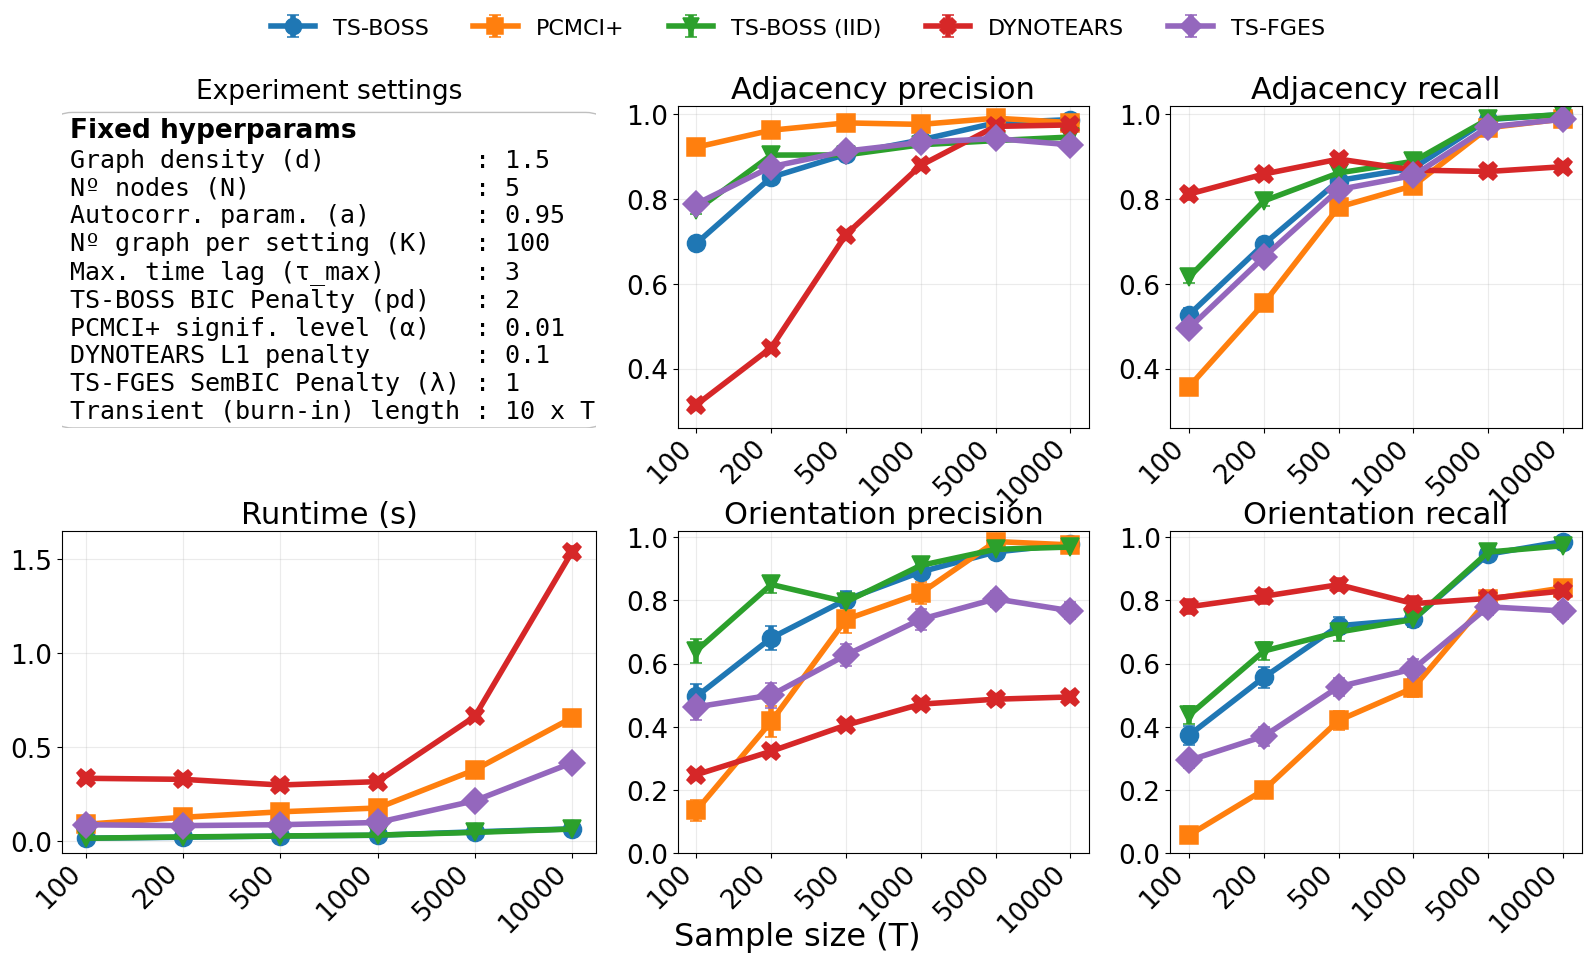

In [12]:
# JSON-based plotting (same format) 
json_candidates = sorted(glob.glob(os.path.join(results_folder, "nsamplesize_experiments_default_*.json")))
if not json_candidates:
    raise FileNotFoundError("No JSON found for sample size experiment in results folder.")
json_name = os.path.basename(json_candidates[-1])
print("Using JSON:", json_name)

plot_experiments_json(
    name=json_name,
    folder=results_folder,
    comparison_type="vs_cpdag",
    varied_param="T",
    fixed_params=fixed_params,
    methods=["tsboss", "pcmci", "tsboss_iid", "dynotears", "svarfges"],
    base_font= 16,
    fixed_params_font = 16
)

### 7.2 Graph Density Results

In [13]:
fixed_params = {    
    "Nº samples (T)": 1000,  
    # "Graph density (d)": 1.5,  
    "Nº nodes (N)": 5,
    #"Nº links (L)": r"$1.5 \times N$",
    "Autocorr. param. (a)": 0.95,
    "Nº graph per setting (K)": 100,
    "Max. time lag (τ_max)": 3,
    "TS-BOSS BIC Penalty (pd)": 2,
    "PCMCI+ signif. level (α)": 0.01,
    #"Contemp. collider rule": "Majority",
    "DYNOTEARS L1 penalty": 0.1,  
    "TS-FGES SemBIC Penalty (λ)": 1,
    "Transient (burn-in) length": r"$10 \times T$",
}

Using JSON: avgdegree_experiments_default_20260411_183918.json


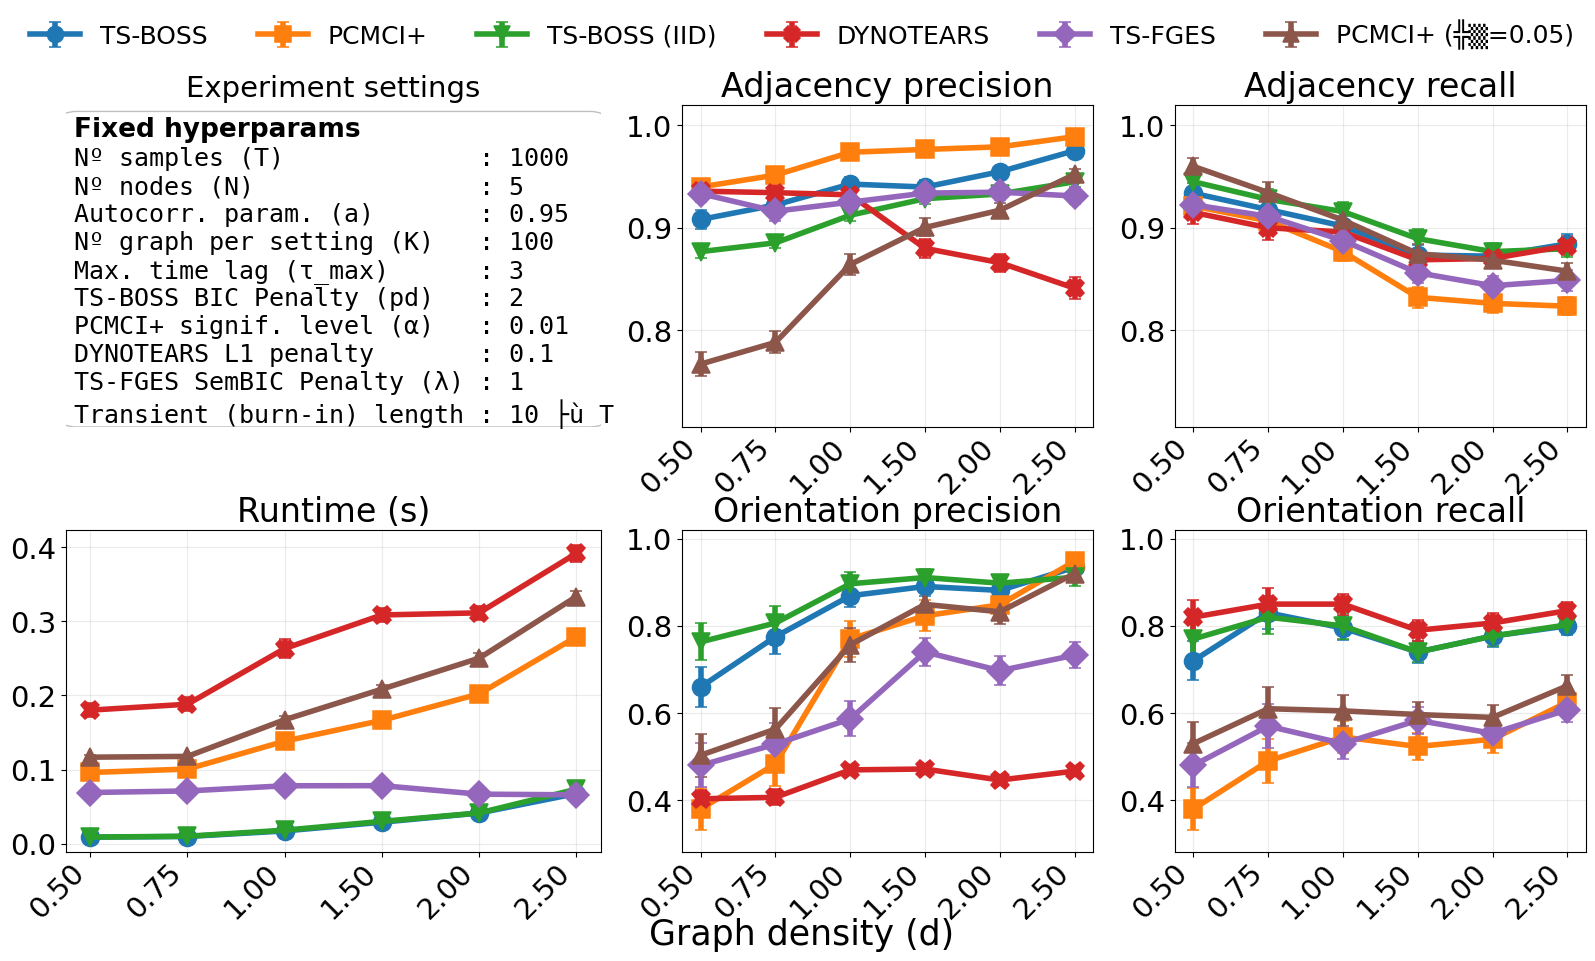

In [15]:
# JSON-based plotting (same format) 
json_candidates = sorted(glob.glob(os.path.join(results_folder, "avgdegree_experiments_default*.json")))
if not json_candidates:
    raise FileNotFoundError("No JSON found for graph density experiment in results folder.")
json_name = os.path.basename(json_candidates[-1])
print("Using JSON:", json_name)

plot_experiments_json(
    name=json_name,
    folder=results_folder,
    comparison_type="vs_cpdag",
    varied_param="degree",
    fixed_params=fixed_params,
    methods=["tsboss", "pcmci", "tsboss_iid",  "dynotears", "svarfges", "pcmci_alpha_0.05"],
    base_font= 18,
    fixed_params_font = 16
)

### 7.3 Number of Nodes Results

In [16]:
fixed_params = {    
    "Nº samples (T)": 1000,  
    "Graph density (d)": 1.5,  
    # "Nº nodes (N)": 5,
    #"Nº links (L)": r"$1.5 \times N$",
    "Autocorr. param. (a)": 0.95,
    "Nº graph per setting (K)": 100,
    "Max. time lag (τ_max)": 3,
    "TS-BOSS BIC Penalty (pd)": 2,
    "PCMCI+ signif. level (α)": 0.01,
    #"Contemp. collider rule": "Majority",
    "DYNOTEARS L1 penalty": 0.1,  
    "TS-FGES SemBIC Penalty (λ)": 1,
    "Transient (burn-in) length": r"$10 \times T$",
}

Using JSON: nodes_experiments_default_20260411_222151.json


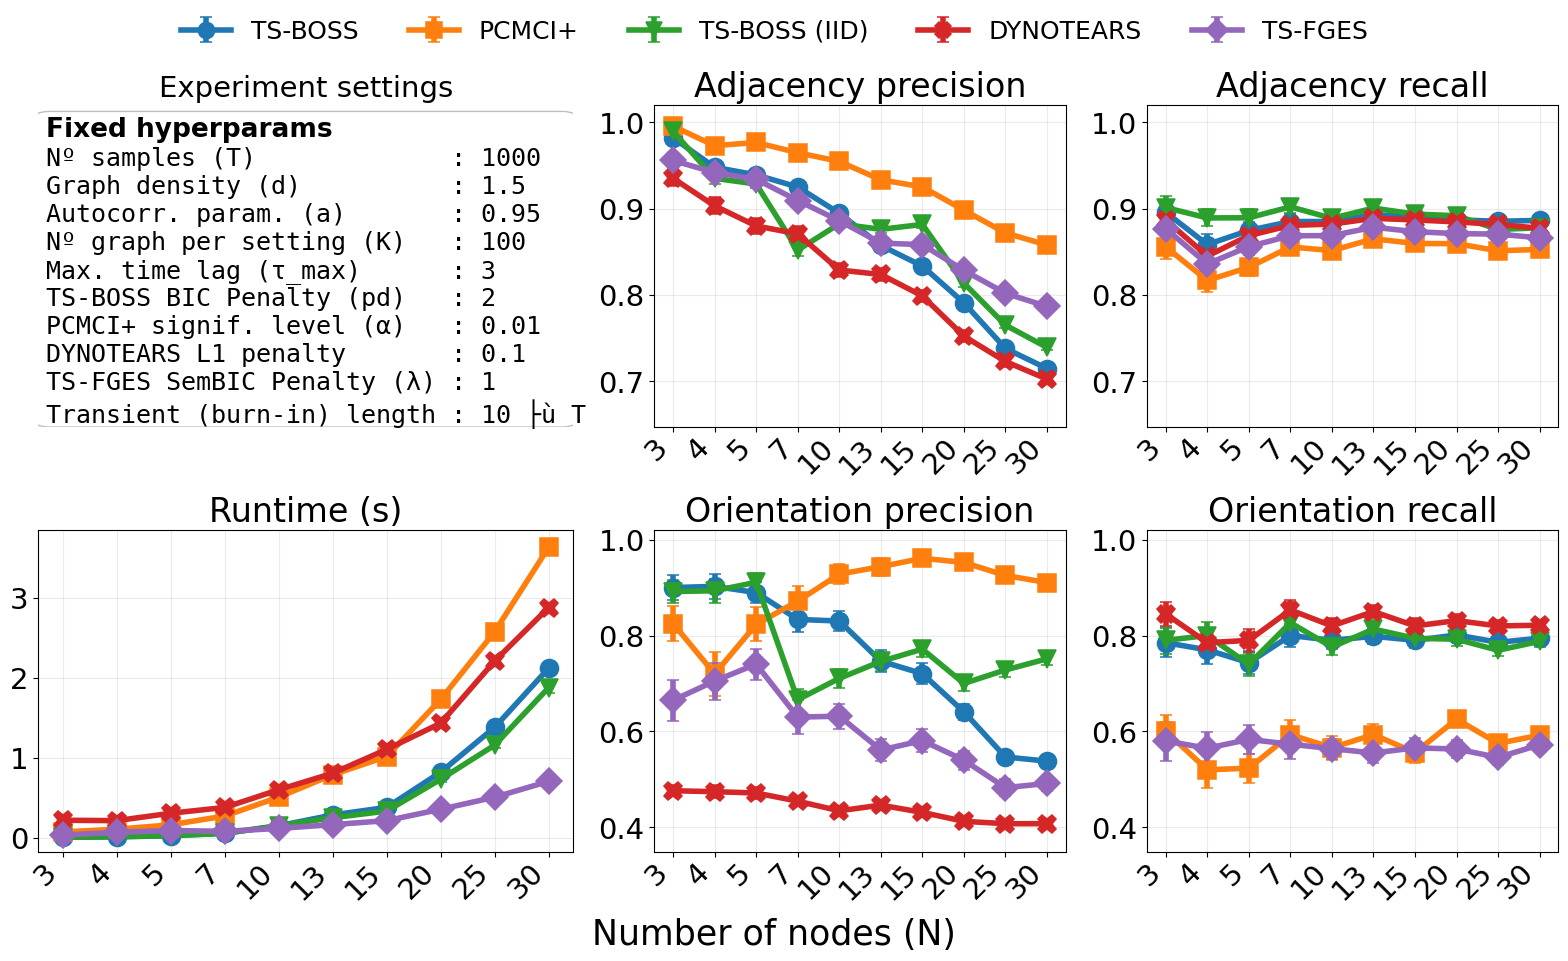

In [20]:
# JSON-based plotting (same format) 
json_candidates = sorted(glob.glob(os.path.join(results_folder, "nodes_experiments_default*.json")))

# json_candidates = sorted(glob.glob(os.path.join(results_folder, "nodes_experiments_default*.json")))
if not json_candidates:
    raise FileNotFoundError("No JSON found for number-of-nodes experiment in results folder.")
json_name = os.path.basename(json_candidates[-1])
print("Using JSON:", json_name)

plot_experiments_json(
    name=json_name,
    folder=results_folder,
    comparison_type="vs_cpdag",
    varied_param="N_nodes",
    fixed_params=fixed_params,
    methods=["tsboss", "pcmci", "tsboss_iid", "dynotears", "svarfges"],
    base_font= 18,
    fixed_params_font = 16
)

Using JSON: nodes_experiments_ac095_20260508_065447.json


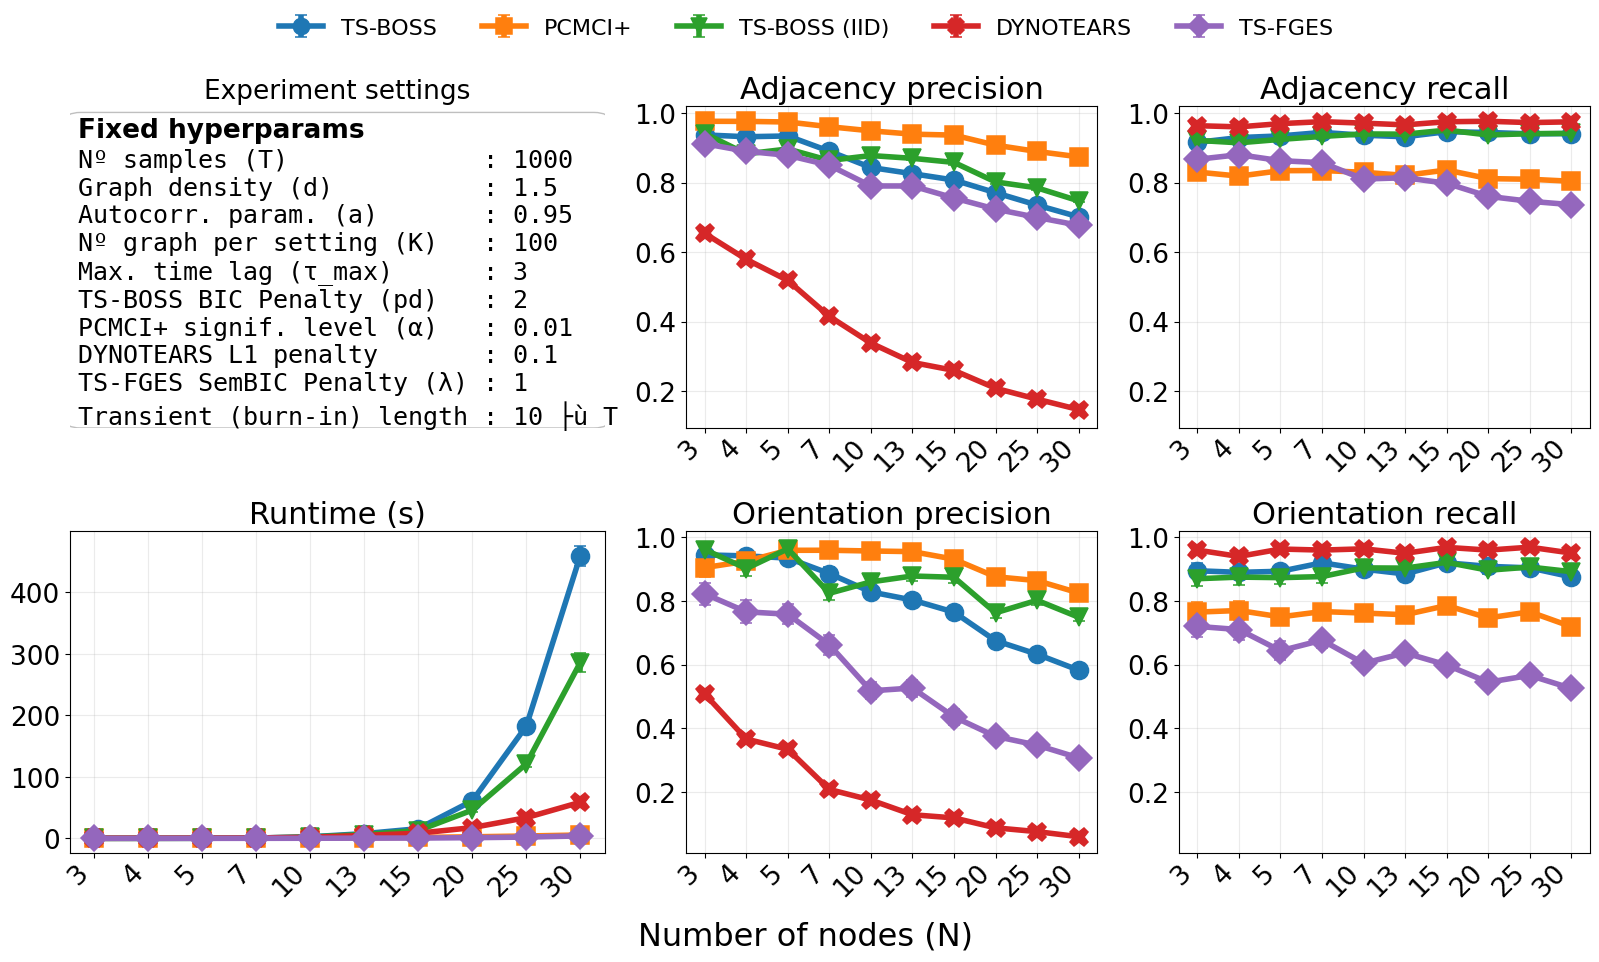

In [22]:
# JSON-based plotting (same format) - Section 7.3
json_candidates = sorted(glob.glob(os.path.join(results_folder, "nodes_experiments_ac095_20260508_065447.json")))

# json_candidates = sorted(glob.glob(os.path.join(results_folder, "nodes_experiments_default*.json")))
if not json_candidates:
    raise FileNotFoundError("No JSON found for number-of-nodes experiment in results folder.")
json_name = os.path.basename(json_candidates[-1])
print("Using JSON:", json_name)

plot_experiments_json(
    name=json_name,
    folder=results_folder,
    comparison_type="vs_cpdag",
    varied_param="N_nodes",
    fixed_params=fixed_params,
    methods=["tsboss", "pcmci", "tsboss_iid", "dynotears", "svarfges"],
    base_font= 16,
    fixed_params_font = 16
)

### 7.4 Autocorrelation Results

In [53]:
fixed_params = {    
    "Nº samples (T)": 1000,  
    "Graph density (d)": 1.5,  
    "Nº nodes (N)": 5,
    #"Nº links (L)": r"$1.5 \times N$",
    # "Autocorr. param. (a)": 0.3,
    "Nº graph per setting (K)": 100,
    "Max. time lag (τ_max)": 3,
    "TS-BOSS BIC Penalty (pd)": 2,
    "PCMCI+ signif. level (α)": 0.01,
    #"Contemp. collider rule": "Majority",
    "DYNOTEARS L1 penalty": 0.1,  
    "TS-FGES SemBIC Penalty (λ)": 1,
    "Transient (burn-in) length": r"10 \times T",
}

Using JSON: autocorrelation_experiments_02_all_20260412_222539.json


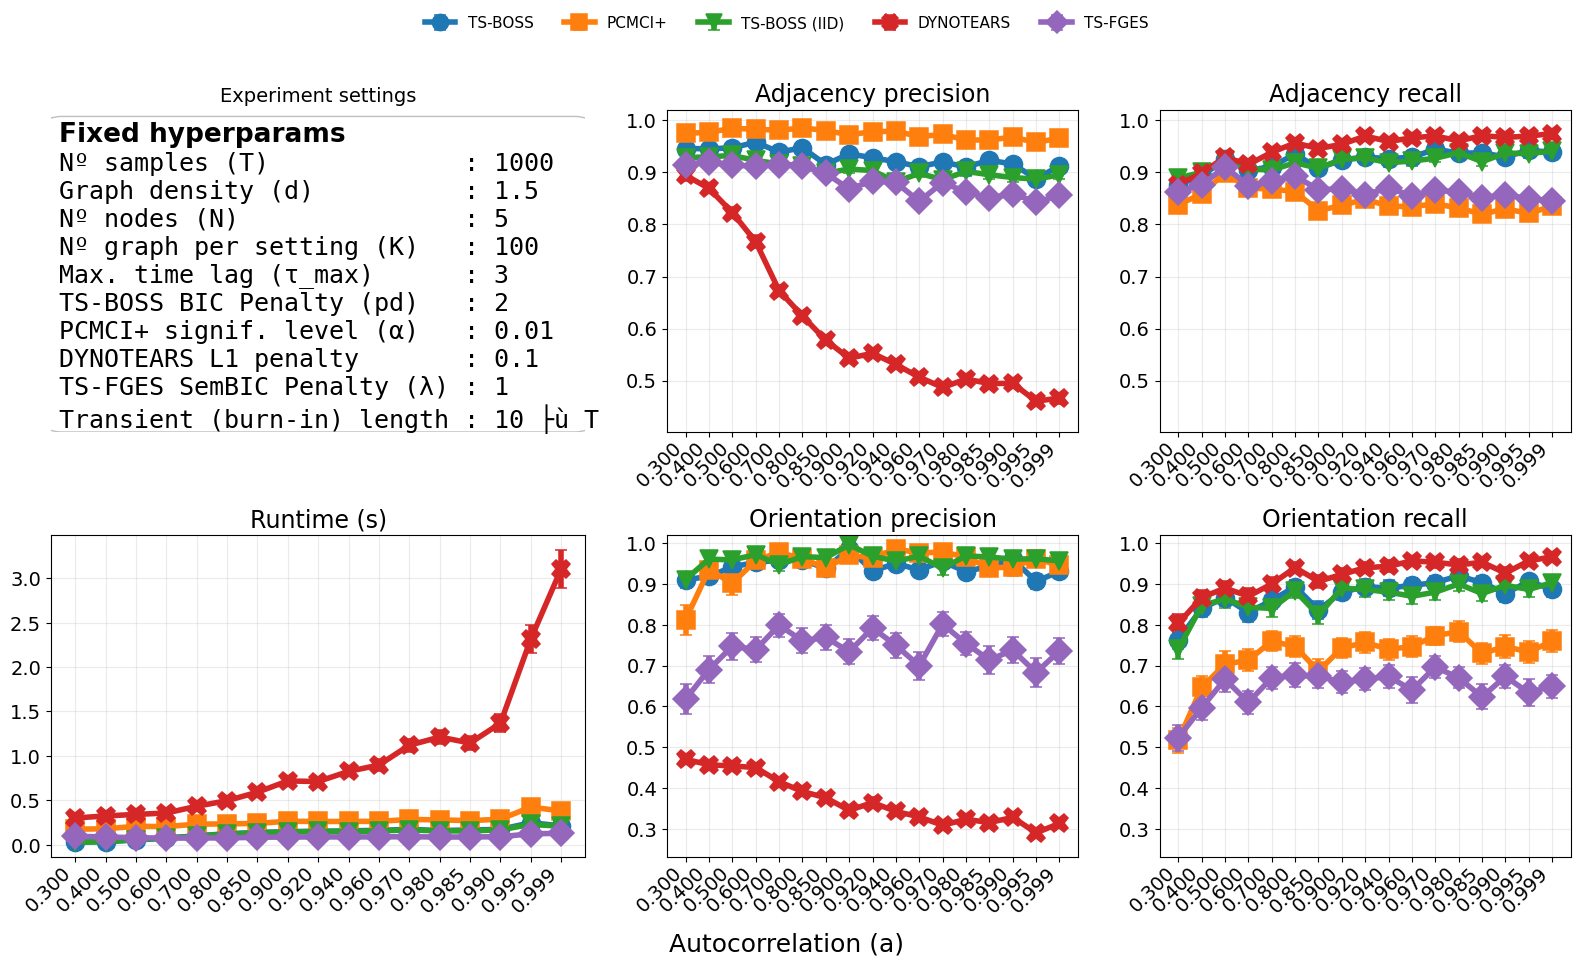

In [54]:

json_candidates = sorted(glob.glob(os.path.join(results_folder, "autocorrelation_experiments_02*.json")))
if not json_candidates:
    print("No autocorrelation JSON found yet. Run/save Experiment 4 first, then rerun this cell.")
else:
    json_name = os.path.basename(json_candidates[-1])
    print("Using JSON:", json_name)

    plot_experiments_json(
        name=json_name,
        folder=results_folder,
        comparison_type="vs_DAG",
        varied_param="autocorrelation",
        fixed_params=fixed_params,
        methods=["tsboss", "pcmci", "tsboss_iid", "dynotears", "svarfges"],
        base_font= 11,
        fixed_params_font = 16
    )

## 8. Adjacency Component Plots 

This section plots adjacency components with a fixed-parameters table in the first quadrant, and three panels for contemporaneous, lagged, and autoregressive adjacency metrics.

In [28]:
results_folder = os.path.join(PROJECT_ROOT, "results")


def latest_json_or_none(pattern: str):
    candidates = sorted(glob.glob(os.path.join(results_folder, pattern)))
    return candidates[-1] if candidates else None


def plot_components_from_latest(pattern, varied_param, fixed_params, metric="f1", methods=None):
    json_path = latest_json_or_none(pattern)
    if json_path is None:
        print(f"No JSON found for pattern: {pattern}")
        return

    print(f"Using JSON: {os.path.basename(json_path)}")

    plot_adjacency_components_json(
        name=os.path.basename(json_path),
        folder=results_folder,
        comparison_type="cpdag",
        varied_param=varied_param,
        fixed_params=fixed_params,
        methods=methods,
        metric=metric,
        rotate_xticks=35,
        figsize=(30, 1.5),
        base_font=20,
        fixed_params_font=20,
        
    )

### 8.1 Experiment 1: Varying Sample Size

Using JSON: nsamplesize_experiments_default_20260411_160847.json


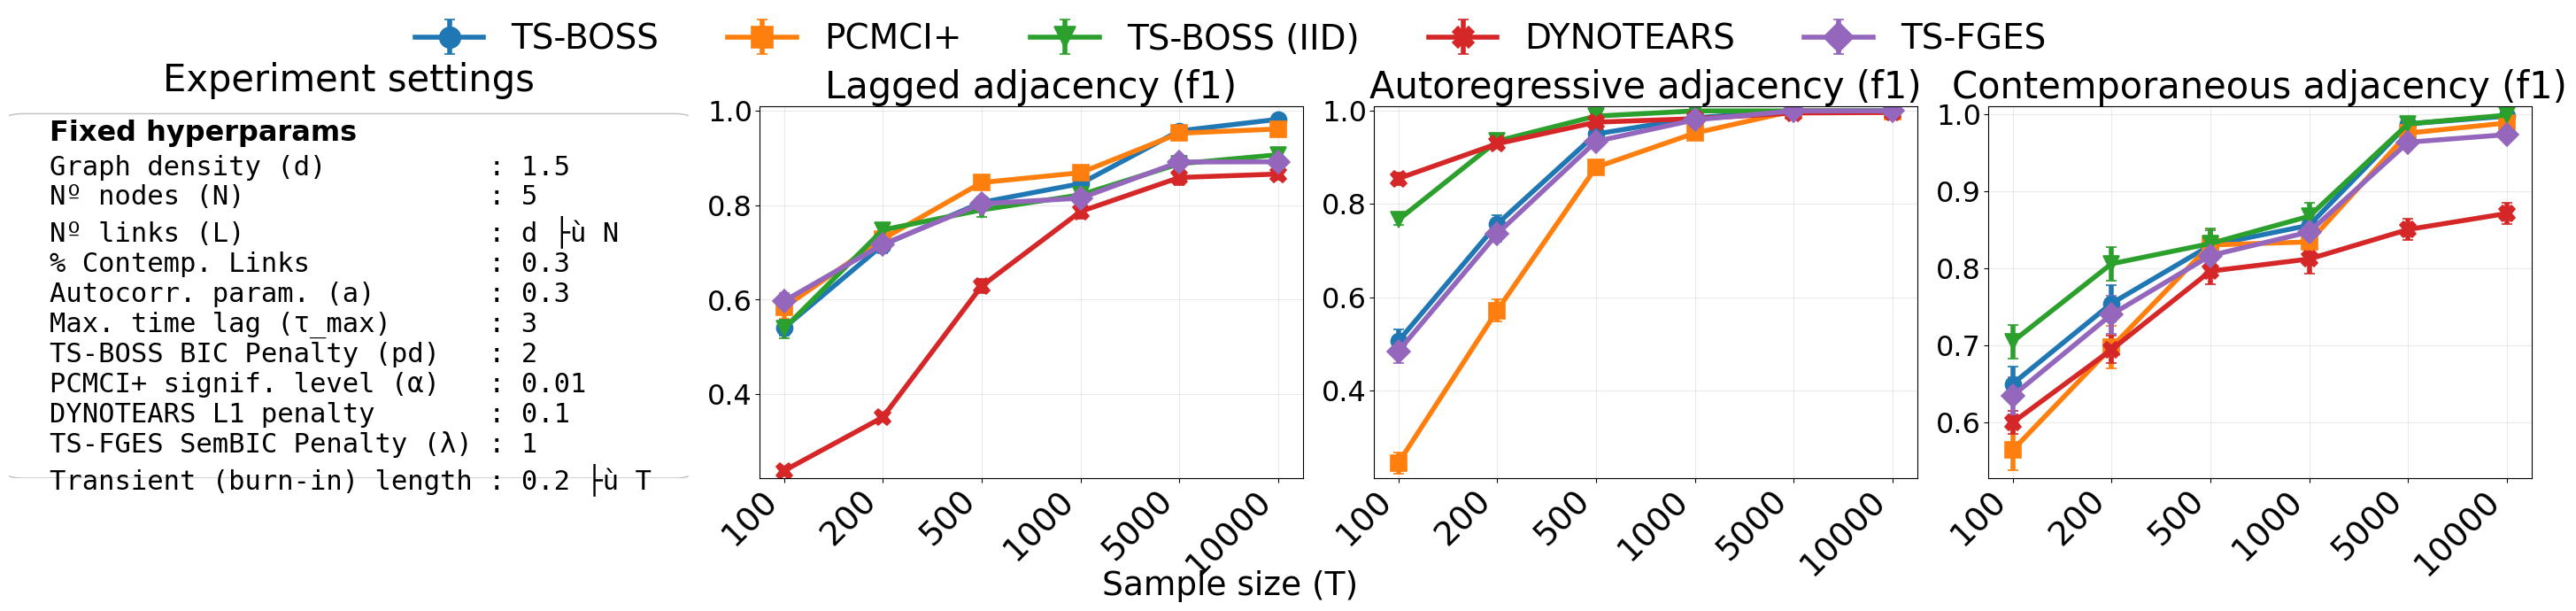

In [29]:
fixed_exp1 = {    
    # "Nº samples (T)": 1000,  
    "Graph density (d)": 1.5,  
    "Nº nodes (N)": 5,
    "Nº links (L)": r"$d \times N$",
    "% Contemp. Links": 0.3,
    "Autocorr. param. (a)": 0.3,
    # "Nº graph per setting (K)": 100,
    "Max. time lag (τ_max)": 3,
    "TS-BOSS BIC Penalty (pd)": 2,
    "PCMCI+ signif. level (α)": 0.01,
    #"Contemp. collider rule": "Majority",
    "DYNOTEARS L1 penalty": 0.1,  
    "TS-FGES SemBIC Penalty (λ)": 1,
    "Transient (burn-in) length": r"$0.2 \times T$",
}

plot_components_from_latest(
    pattern="nsamplesize_experiments_default_*.json",
    varied_param="T",
    fixed_params=fixed_exp1,
    metric="f1",
    methods=["tsboss", "pcmci", "tsboss_iid", "dynotears", "svarfges"]
)

### 8.2 Experiment 2: Varying Graph Density

Using JSON: avgdegree_experiments_default_20260411_183918.json


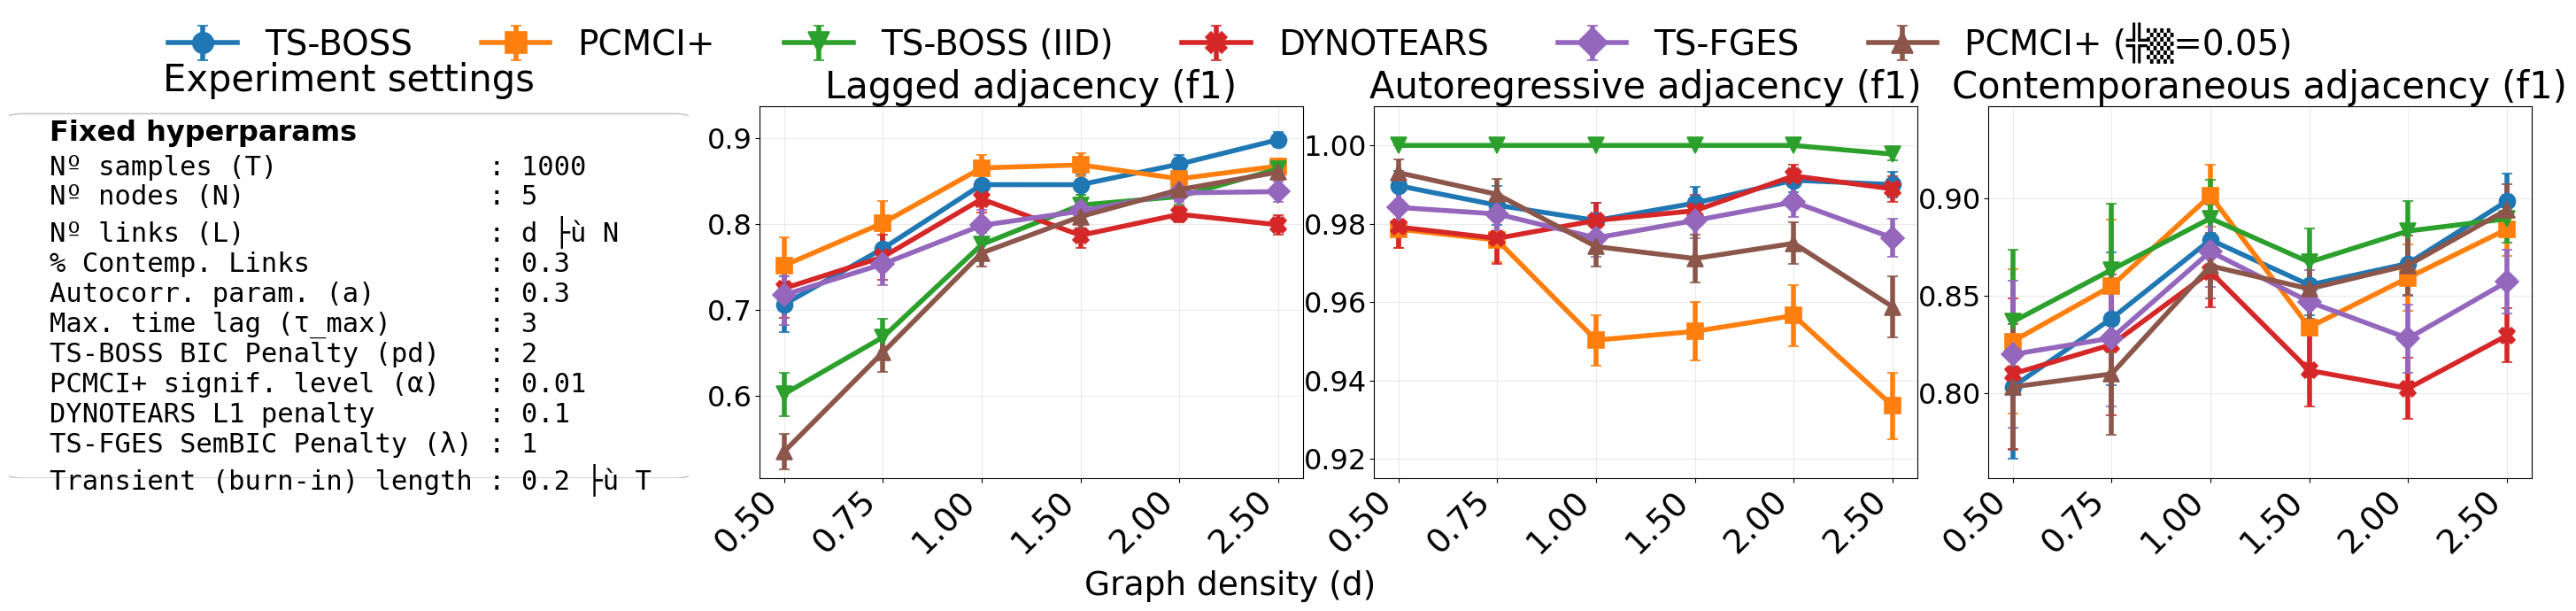

In [31]:
fixed_exp2 = {    
    "Nº samples (T)": 1000,  
    # "Graph density (d)": 1.5,  
    "Nº nodes (N)": 5,
    "Nº links (L)": r"$d \times N$",
    "% Contemp. Links": 0.3,
    "Autocorr. param. (a)": 0.3,
    # "Nº graph per setting (K)": 100,
    "Max. time lag (τ_max)": 3,
    "TS-BOSS BIC Penalty (pd)": 2,
    "PCMCI+ signif. level (α)": 0.01,
    #"Contemp. collider rule": "Majority",
    "DYNOTEARS L1 penalty": 0.1,  
    "TS-FGES SemBIC Penalty (λ)": 1,
    "Transient (burn-in) length": r"$0.2 \times T$",
}

plot_components_from_latest(
    pattern="avgdegree_experiments_default_*.json",
    varied_param="degree",
    fixed_params=fixed_exp2,
    metric="f1",
    methods=["tsboss", "pcmci", "tsboss_iid", "dynotears", "svarfges", "pcmci_alpha_0.05"],
)

### 8.3 Experiment 3: Varying Number of Nodes

Using JSON: nodes_experiments_default_20260411_222151.json


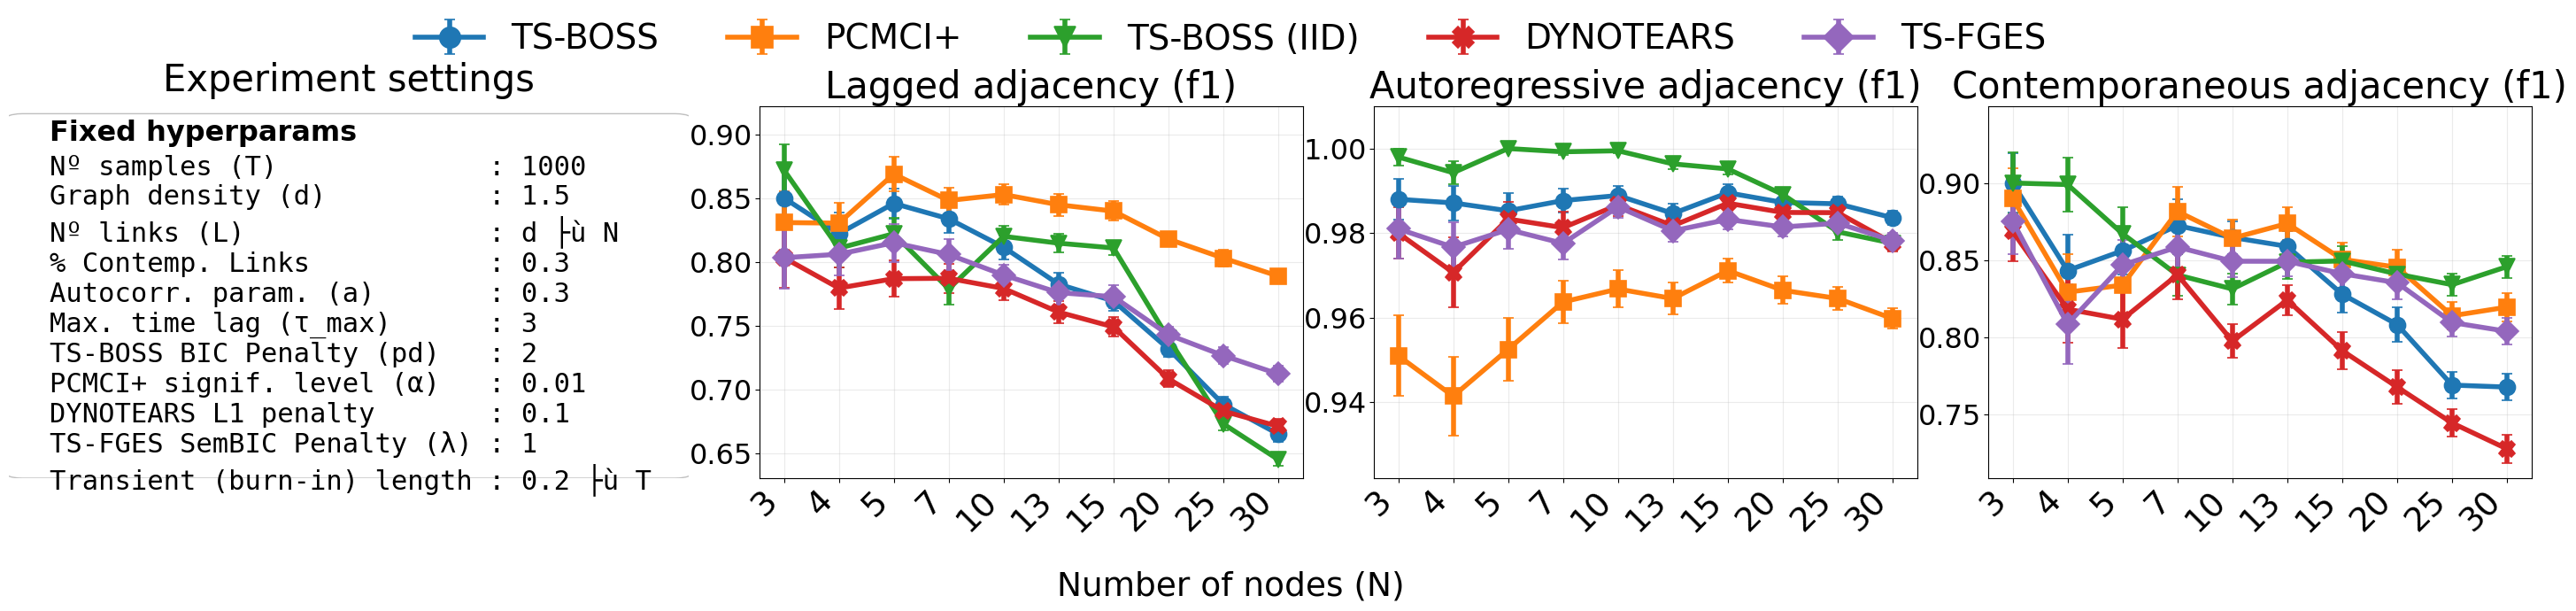

In [33]:
fixed_exp3 = {    
    "Nº samples (T)": 1000,  
    "Graph density (d)": 1.5,  
    # "Nº nodes (N)": 5,
    "Nº links (L)": r"$d \times N$",
    "% Contemp. Links": 0.3,
    "Autocorr. param. (a)": 0.3,
    # "Nº graph per setting (K)": 100,
    "Max. time lag (τ_max)": 3,
    "TS-BOSS BIC Penalty (pd)": 2,
    "PCMCI+ signif. level (α)": 0.01,
    #"Contemp. collider rule": "Majority",
    "DYNOTEARS L1 penalty": 0.1,  
    "TS-FGES SemBIC Penalty (λ)": 1,
    "Transient (burn-in) length": r"$0.2 \times T$",
}




plot_components_from_latest(
    pattern="nodes_experiments_default_*.json",
    varied_param="N_nodes",
    fixed_params=fixed_exp3,
    methods=["tsboss", "pcmci", "tsboss_iid", "dynotears", "svarfges"],
    metric="f1",
)

### 8.4 Experiment 4: Varying Autocorrelation

Using JSON: autocorrelation_experiments_02_all_20260412_222539.json
None


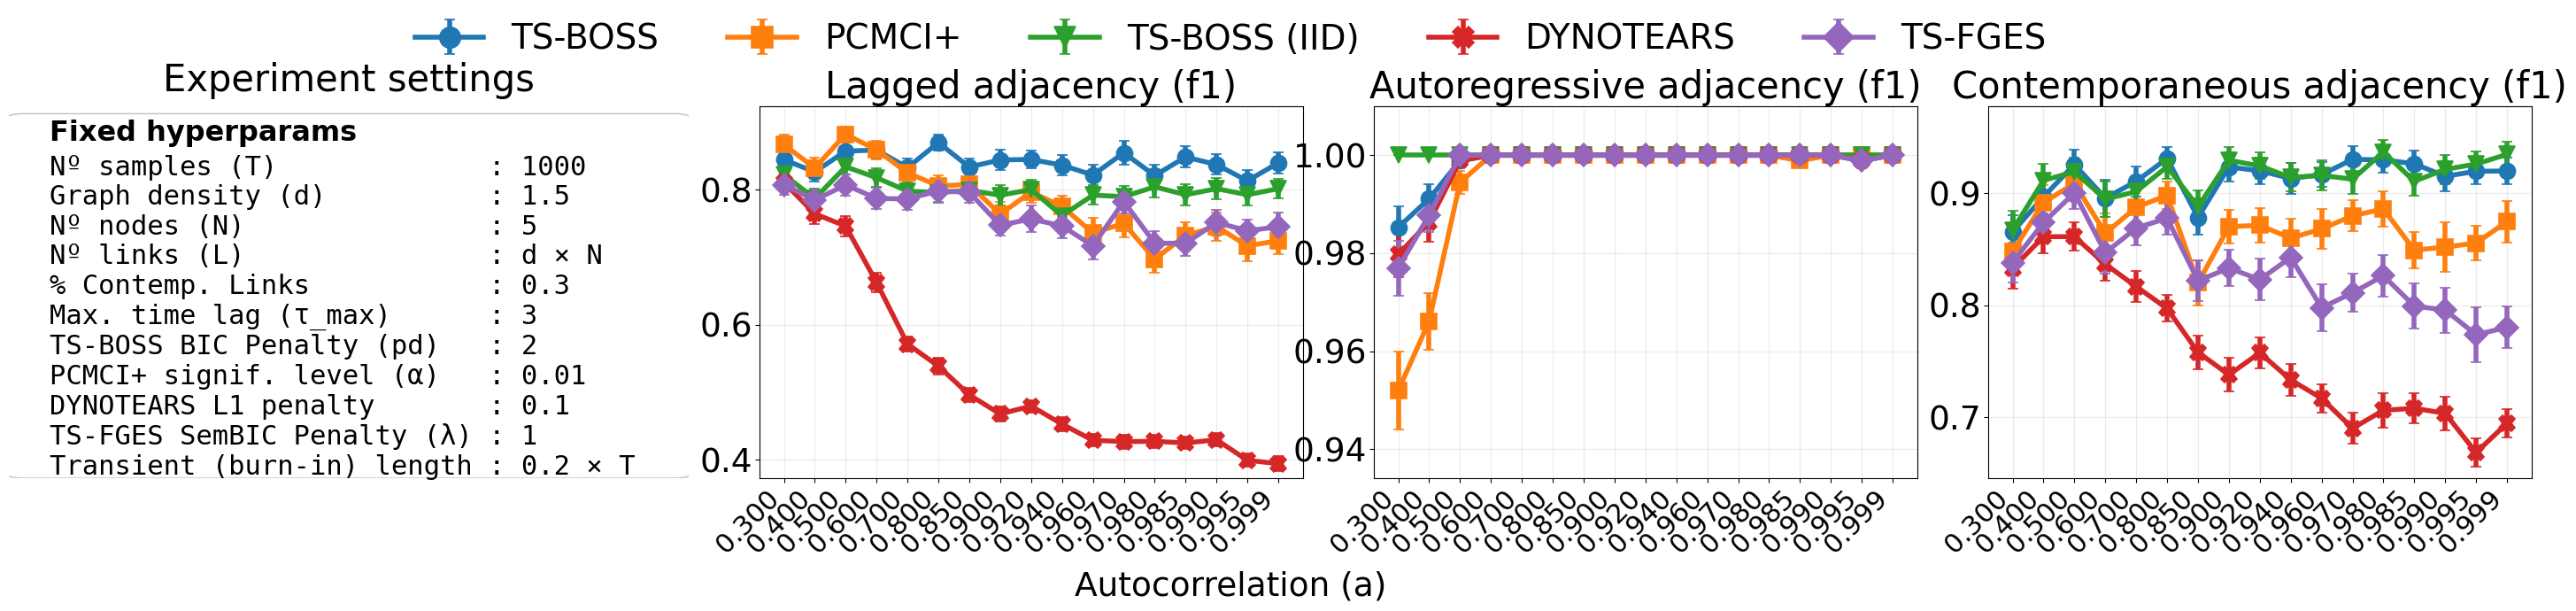

In [3]:
fixed_exp4 = {    
    "Nº samples (T)": 1000,  
    "Graph density (d)": 1.5,  
    "Nº nodes (N)": 5,
    "Nº links (L)": r"$d \times N$",
    "% Contemp. Links": 0.3,
    #"Autocorr. param. (a)": 0.3,
    # "Nº graph per setting (K)": 100,
    "Max. time lag (τ_max)": 3,
    "TS-BOSS BIC Penalty (pd)": 2,
    "PCMCI+ signif. level (α)": 0.01,
    #"Contemp. collider rule": "Majority",
    "DYNOTEARS L1 penalty": 0.1,  
    "TS-FGES SemBIC Penalty (λ)": 1,
    "Transient (burn-in) length": r"$0.2 \times T$",
}


plot_components_from_latest(
    pattern="autocorrelation_experiments*.json",
    varied_param="autocorrelation",
    fixed_params=fixed_exp4,
    title=None,
    metric="f1",
    methods=["tsboss", "pcmci", "tsboss_iid", "dynotears", "svarfges"],
)